
# **IMPORTAR** **LIBRERIAS**

In [1617]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.model_selection import KFold, cross_validate
from statsmodels.stats.outliers_influence import variance_inflation_factor
import shap

import warnings
warnings.filterwarnings("ignore")

# Outliers / estadística
from scipy.stats import zscore, median_abs_deviation
from scipy.stats.mstats import winsorize

# pyod (MAD) - import seguro por si no está instalado
try:
    from pyod.models.mad import MAD
    _HAS_PYOD = True
except Exception as e:
    _HAS_PYOD = False
    print("Aviso: pyod no disponible (MAD). Si lo necesitas: pip install pyod")

# Modelado
from sklearn.model_selection import train_test_split, learning_curve, ShuffleSplit
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor

# XGBoost + interpretabilidad
from xgboost import XGBRegressor

# SHAP (import seguro)
try:
    import shap
    shap.initjs()
    _HAS_SHAP = True
except Exception as e:
    _HAS_SHAP = False
    print("Aviso: shap no se pudo importar:", e)

# **CONTRUCCIÓN Y ANÁLISIS EXPLORATORIO DEL SUBCONJUNTO**

## ***CONTRUCCIÓN DEL CONJUNTO DE DATOS***

In [1618]:
# Carga de los datos.

file_path = 'Póliza-Siniestro.csv'
df = pd.read_csv(file_path, low_memory = False)
df.head()

,Tipo de Vehiculo,Marca,Deducible,Cobertura,Entidad,Tipo de Perdida,Subtipo de Seguro,Causa del siniestro,Numero de Vehiculos,Prima Emitida,...,Prima Devengada Acumulada,Comision Directa,Suma Asegurada,Monto de Siniestros,Monto Pagado,Salvamentos,Gastos de Ajuste,Monto de Deducible,Monto Reaseguro,Monto Recuperado
0,12,7855,7,1,14,1,0,6,2,48640.18,...,59828,5054.49,0,1.088949e+06,1.088949e+06,0.00,1761.240000,0.0,0.00,0.0
1,1,136,5,1,32,2,0,6,2,2096.63,...,3685,314.50,0,1.999421e+05,1.129200e+05,72474.31,20470.400000,5680.0,0.00,0.0
2,1,781,0,3,16,7,0,6,2,976.24,...,1263,0.00,7000000,3.937501e+04,3.939364e+04,0.00,1.964514,0.0,0.00,0.0
3,1,632,1,2,25,2,0,14,7,6902.08,...,7257,0.00,0,2.887170e+06,8.410300e+05,152770.00,5846.400000,152770.0,1204915.64,0.0
4,1,79,0,6,2,8,0,6,4,2411.59,...,1440,225.00,880000,-6.400000e+01,0.000000e+00,0.00,0.000000,0.0,0.00,2668.0


In [1619]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159405 entries, 0 to 159404
Data columns (total 22 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Tipo de Vehiculo           159405 non-null  int64  
 1   Marca                      159405 non-null  int64  
 2   Deducible                  159405 non-null  int64  
 3   Cobertura                  159405 non-null  int64  
 4   Entidad                    159405 non-null  int64  
 5   Tipo de Perdida            159405 non-null  int64  
 6   Subtipo de Seguro          159405 non-null  int64  
 7   Causa del siniestro        159405 non-null  int64  
 8   Numero de Vehiculos        159405 non-null  int64  
 9   Prima Emitida              159405 non-null  float64
 10  Prima Cedida               159405 non-null  float64
 11  Prima Devengada            159405 non-null  float64
 12  Prima Devengada Acumulada  159405 non-null  int64  
 13  Comision Directa           15

In [1620]:
# Cargar del sub-catálogo conformado por los catálogos 150 y 151.

df_catalogo150 = pd.read_csv('CAT 150.csv')
df_catalogo150.head()

,ID SESA,MARCA,TIPO,SEGMENTO CLASE,CLASIFICACION,COMBUSTIBLE,MODELO,UNIDADES EXPUESTAS
0,1,GENERAL MOTORS,CHEVELLE NOVA CAPRICE OPEL,COMPACTO,AUTOMOVILES,GASOLINA,1980,5.0135
1,2,GENERAL MOTORS,CITATION CELEBRITYIMPALA Y MALIBU 1981 Y ANTER...,COMPACTO,AUTOMOVILES,GASOLINA,2007,57.9477
2,3,CHRYSLER,DART K VOLARE K,COMPACTO,AUTOMOVILES,GASOLINA,2013,524.6893
3,4,CHRYSLER,CORDOBAMONACO LE BARON CORONET Y VALIANT,COMPACTO,AUTOMOVILES,GASOLINA,2007,57.9477
4,5,CHRYSLER,CHRYSLER 600,COMPACTO,AUTOMOVILES,GASOLINA,1985,57.9477


In [1621]:
# Agregar la nuevas columnas: Unidades Expuestas, Modelo, Segmento Clase y Combustible.

df['Unidades Expuestas'] = df['Marca'].map(df_catalogo150.set_index('ID SESA')['UNIDADES EXPUESTAS'])
df['Modelo'] = df['Marca'].map(df_catalogo150.set_index('ID SESA')['MODELO'])
df['Segmento Clase'] = df['Marca'].map(df_catalogo150.set_index('ID SESA')['SEGMENTO CLASE'])
df['Combustible'] = df['Marca'].map(df_catalogo150.set_index('ID SESA')['COMBUSTIBLE'])
df.head()

,Tipo de Vehiculo,Marca,Deducible,Cobertura,Entidad,Tipo de Perdida,Subtipo de Seguro,Causa del siniestro,Numero de Vehiculos,Prima Emitida,...,Monto Pagado,Salvamentos,Gastos de Ajuste,Monto de Deducible,Monto Reaseguro,Monto Recuperado,Unidades Expuestas,Modelo,Segmento Clase,Combustible
0,12,7855,7,1,14,1,0,6,2,48640.18,...,1.088949e+06,0.00,1761.240000,0.0,0.00,0.0,NaN,NaN,NaN,NaN
1,1,136,5,1,32,2,0,6,2,2096.63,...,1.129200e+05,72474.31,20470.400000,5680.0,0.00,0.0,NaN,NaN,NaN,NaN
2,1,781,0,3,16,7,0,6,2,976.24,...,3.939364e+04,0.00,1.964514,0.0,0.00,0.0,NaN,NaN,NaN,NaN
3,1,632,1,2,25,2,0,14,7,6902.08,...,8.410300e+05,152770.00,5846.400000,152770.0,1204915.64,0.0,86.3891,2022.0,COMPACTO,GASOLINA
4,1,79,0,6,2,8,0,6,4,2411.59,...,0.000000e+00,0.00,0.000000,0.0,0.00,2668.0,NaN,NaN,NaN,NaN


In [1622]:
# Como es de esperarse, no todos los registros resiven asignación de valores del catálogo.
# Por ello revisamos el numero de registros con NaN (nulos).

df.isnull().sum()

Tipo de Vehiculo                  0
Marca                             0
Deducible                         0
Cobertura                         0
Entidad                           0
Tipo de Perdida                   0
Subtipo de Seguro                 0
Causa del siniestro               0
Numero de Vehiculos               0
Prima Emitida                     0
Prima Cedida                      0
Prima Devengada                   0
Prima Devengada Acumulada         0
Comision Directa                  0
Suma Asegurada                    0
Monto de Siniestros               0
Monto Pagado                      0
Salvamentos                       0
Gastos de Ajuste                  0
Monto de Deducible                0
Monto Reaseguro                   0
Monto Recuperado                  0
Unidades Expuestas           113445
Modelo                       113445
Segmento Clase               113445
Combustible                  113445
dtype: int64

## ***FILTROS APLICADOS AL CONJUNTO DE DATOS***

In [1623]:
# Filtrar unicamente por automóviles y Pólizas individuales

df = df[(df['Tipo de Vehiculo'] == 1) & (df['Numero de Vehiculos'] == 1)]
df = df.drop(columns=['Tipo de Vehiculo', 'Numero de Vehiculos'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74022 entries, 8 to 159404
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Marca                      74022 non-null  int64  
 1   Deducible                  74022 non-null  int64  
 2   Cobertura                  74022 non-null  int64  
 3   Entidad                    74022 non-null  int64  
 4   Tipo de Perdida            74022 non-null  int64  
 5   Subtipo de Seguro          74022 non-null  int64  
 6   Causa del siniestro        74022 non-null  int64  
 7   Prima Emitida              74022 non-null  float64
 8   Prima Cedida               74022 non-null  float64
 9   Prima Devengada            74022 non-null  float64
 10  Prima Devengada Acumulada  74022 non-null  int64  
 11  Comision Directa           74022 non-null  float64
 12  Suma Asegurada             74022 non-null  int64  
 13  Monto de Siniestros        74022 non-null  float64

In [1624]:
# Filtrar los datos por los segmentos de interés
# En este caso, se filtran los segmentos Subcompactos y Compactos

segmentos = ['COMPACTO', 'SUBCOMPACTO']
df_filtrado = df[df['Segmento Clase'].isin(segmentos)]
df_filtrado.head()

,Marca,Deducible,Cobertura,Entidad,Tipo de Perdida,Subtipo de Seguro,Causa del siniestro,Prima Emitida,Prima Cedida,Prima Devengada,...,Monto Pagado,Salvamentos,Gastos de Ajuste,Monto de Deducible,Monto Reaseguro,Monto Recuperado,Unidades Expuestas,Modelo,Segmento Clase,Combustible
10,1094,20,99,15,3,0,99,2205.91,0.0,831.74,...,0.00,0.0,1261.41,0.00,0.0,0.0,777.2095,2025.0,COMPACTO,HIBRIDO
12,88,5,1,22,5,0,6,0.00,0.0,2461.25,...,6128.99,0.0,80.00,0.00,0.0,0.0,1131.2844,1999.0,COMPACTO,GASOLINA
14,125,0,1,17,2,0,99,0.00,0.0,432.85,...,447911.17,245500.0,11195.60,0.00,0.0,0.0,86.3891,2016.0,SUBCOMPACTO,GASOLINA/DIESEL
23,405,50,1,30,4,0,6,1258.08,0.0,224.04,...,1832.00,0.0,109.03,0.01,0.0,0.0,1131.2844,2015.0,SUBCOMPACTO,GASOLINA
39,8,5,2,11,2,0,16,-526.03,0.0,0.00,...,76912.00,0.0,0.00,16192.00,0.0,0.0,1131.2844,2010.0,SUBCOMPACTO,GASOLINA


In [1625]:
# Unicamente Conservar Montos de Siniestros mayores a 0

df_sub = df_filtrado[df_filtrado["Monto de Siniestros"] > 0].copy()
df_sub.reset_index(drop=True, inplace=True)

In [1626]:
# Asignar adecuadamente el Dtype a cada variable

col_categoricas = ['Marca', 'Cobertura', 'Entidad', 'Tipo de Perdida', 'Subtipo de Seguro', 'Causa del siniestro', 'Segmento Clase', 'Combustible']

df_sub[col_categoricas] = df_sub[col_categoricas].astype(object)
df_sub['Unidades Expuestas'] = df_sub['Unidades Expuestas'].astype(float)
df_sub['Modelo'] = df_sub['Modelo'].astype(int)

In [1627]:
# Eliminar variables que son consideradas post-siniestro

variables_post_siniestro = ['Monto Pagado', 'Monto Reaseguro', 'Monto de Deducible','Salvamentos', 'Monto Recuperado', 'Gastos de Ajuste']

df_sub.drop(columns = variables_post_siniestro, inplace=True)

In [1628]:
df_sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21204 entries, 0 to 21203
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Marca                      21204 non-null  object 
 1   Deducible                  21204 non-null  int64  
 2   Cobertura                  21204 non-null  object 
 3   Entidad                    21204 non-null  object 
 4   Tipo de Perdida            21204 non-null  object 
 5   Subtipo de Seguro          21204 non-null  object 
 6   Causa del siniestro        21204 non-null  object 
 7   Prima Emitida              21204 non-null  float64
 8   Prima Cedida               21204 non-null  float64
 9   Prima Devengada            21204 non-null  float64
 10  Prima Devengada Acumulada  21204 non-null  int64  
 11  Comision Directa           21204 non-null  float64
 12  Suma Asegurada             21204 non-null  int64  
 13  Monto de Siniestros        21204 non-null  flo

## ***EDA DEL SUBCONJUNTO DE DATOS***

### VARIABLES NUMÉRICAS

#### MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN

In [1629]:
# Considerar unicamente variables numéricas por ello crear una DataFrame temporal.

df_num = df_sub.select_dtypes('number')
df_num.describe().T

,count,mean,std,min,25%,50%,75%,max
Deducible,21204.0,7.350972,11.346469,0.000000,1.0000,5.0000,10.0000,5.000000e+02
Prima Emitida,21204.0,1736.526673,6057.413559,-81854.660000,0.0000,166.5400,2452.3700,5.386749e+05
Prima Cedida,21204.0,98.904344,800.426814,-3511.930000,0.0000,0.0000,0.0000,3.723338e+04
Prima Devengada,21204.0,1429.722181,2928.322716,-2257.040000,137.8375,611.3650,1860.4100,2.796261e+05
Prima Devengada Acumulada,21204.0,2356.189587,4908.767230,-520.000000,238.0000,974.0000,2694.0000,2.796260e+05
Comision Directa,21204.0,122.724585,2313.014076,-7404.280000,0.0000,0.0000,3.4800,3.273871e+05
Suma Asegurada,21204.0,106649.451330,438412.534922,0.000000,0.0000,0.0000,0.0000,6.550000e+06
Monto de Siniestros,21204.0,50221.511484,110329.453719,0.009955,3238.2500,11403.0300,45000.0000,3.300000e+06
Unidades Expuestas,21204.0,391.502817,443.353243,5.013500,57.9477,86.3891,524.6893,1.807343e+03
Modelo,21204.0,2014.509998,8.124442,1971.000000,2010.0000,2016.0000,2021.0000,2.025000e+03


In [1630]:
# Moda de las variables

df_num.mode()

,Deducible,Prima Emitida,Prima Cedida,Prima Devengada,Prima Devengada Acumulada,Comision Directa,Suma Asegurada,Monto de Siniestros,Unidades Expuestas,Modelo
0,0,0.0,0.0,0.0,0,0.0,0,868.0,524.6893,2017


In [1631]:
# Varianza de las variables

df_num.var()

Deducible                    1.287424e+02
Prima Emitida                3.669226e+07
Prima Cedida                 6.406831e+05
Prima Devengada              8.575074e+06
Prima Devengada Acumulada    2.409600e+07
Comision Directa             5.350034e+06
Suma Asegurada               1.922056e+11
Monto de Siniestros          1.217259e+10
Unidades Expuestas           1.965621e+05
Modelo                       6.600655e+01
dtype: float64

#### DISTRIBUCIÓN DE VARIABLES

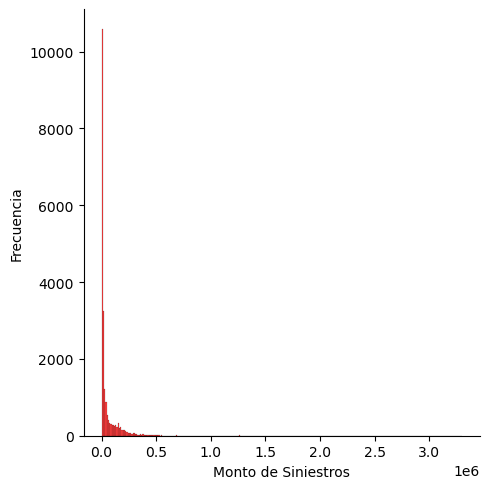

In [1632]:
# Histograma de la variable objetivo

sns.displot(df_num, x = 'Monto de Siniestros', color = 'red')
plt.ylabel("Frecuencia")
plt.show()

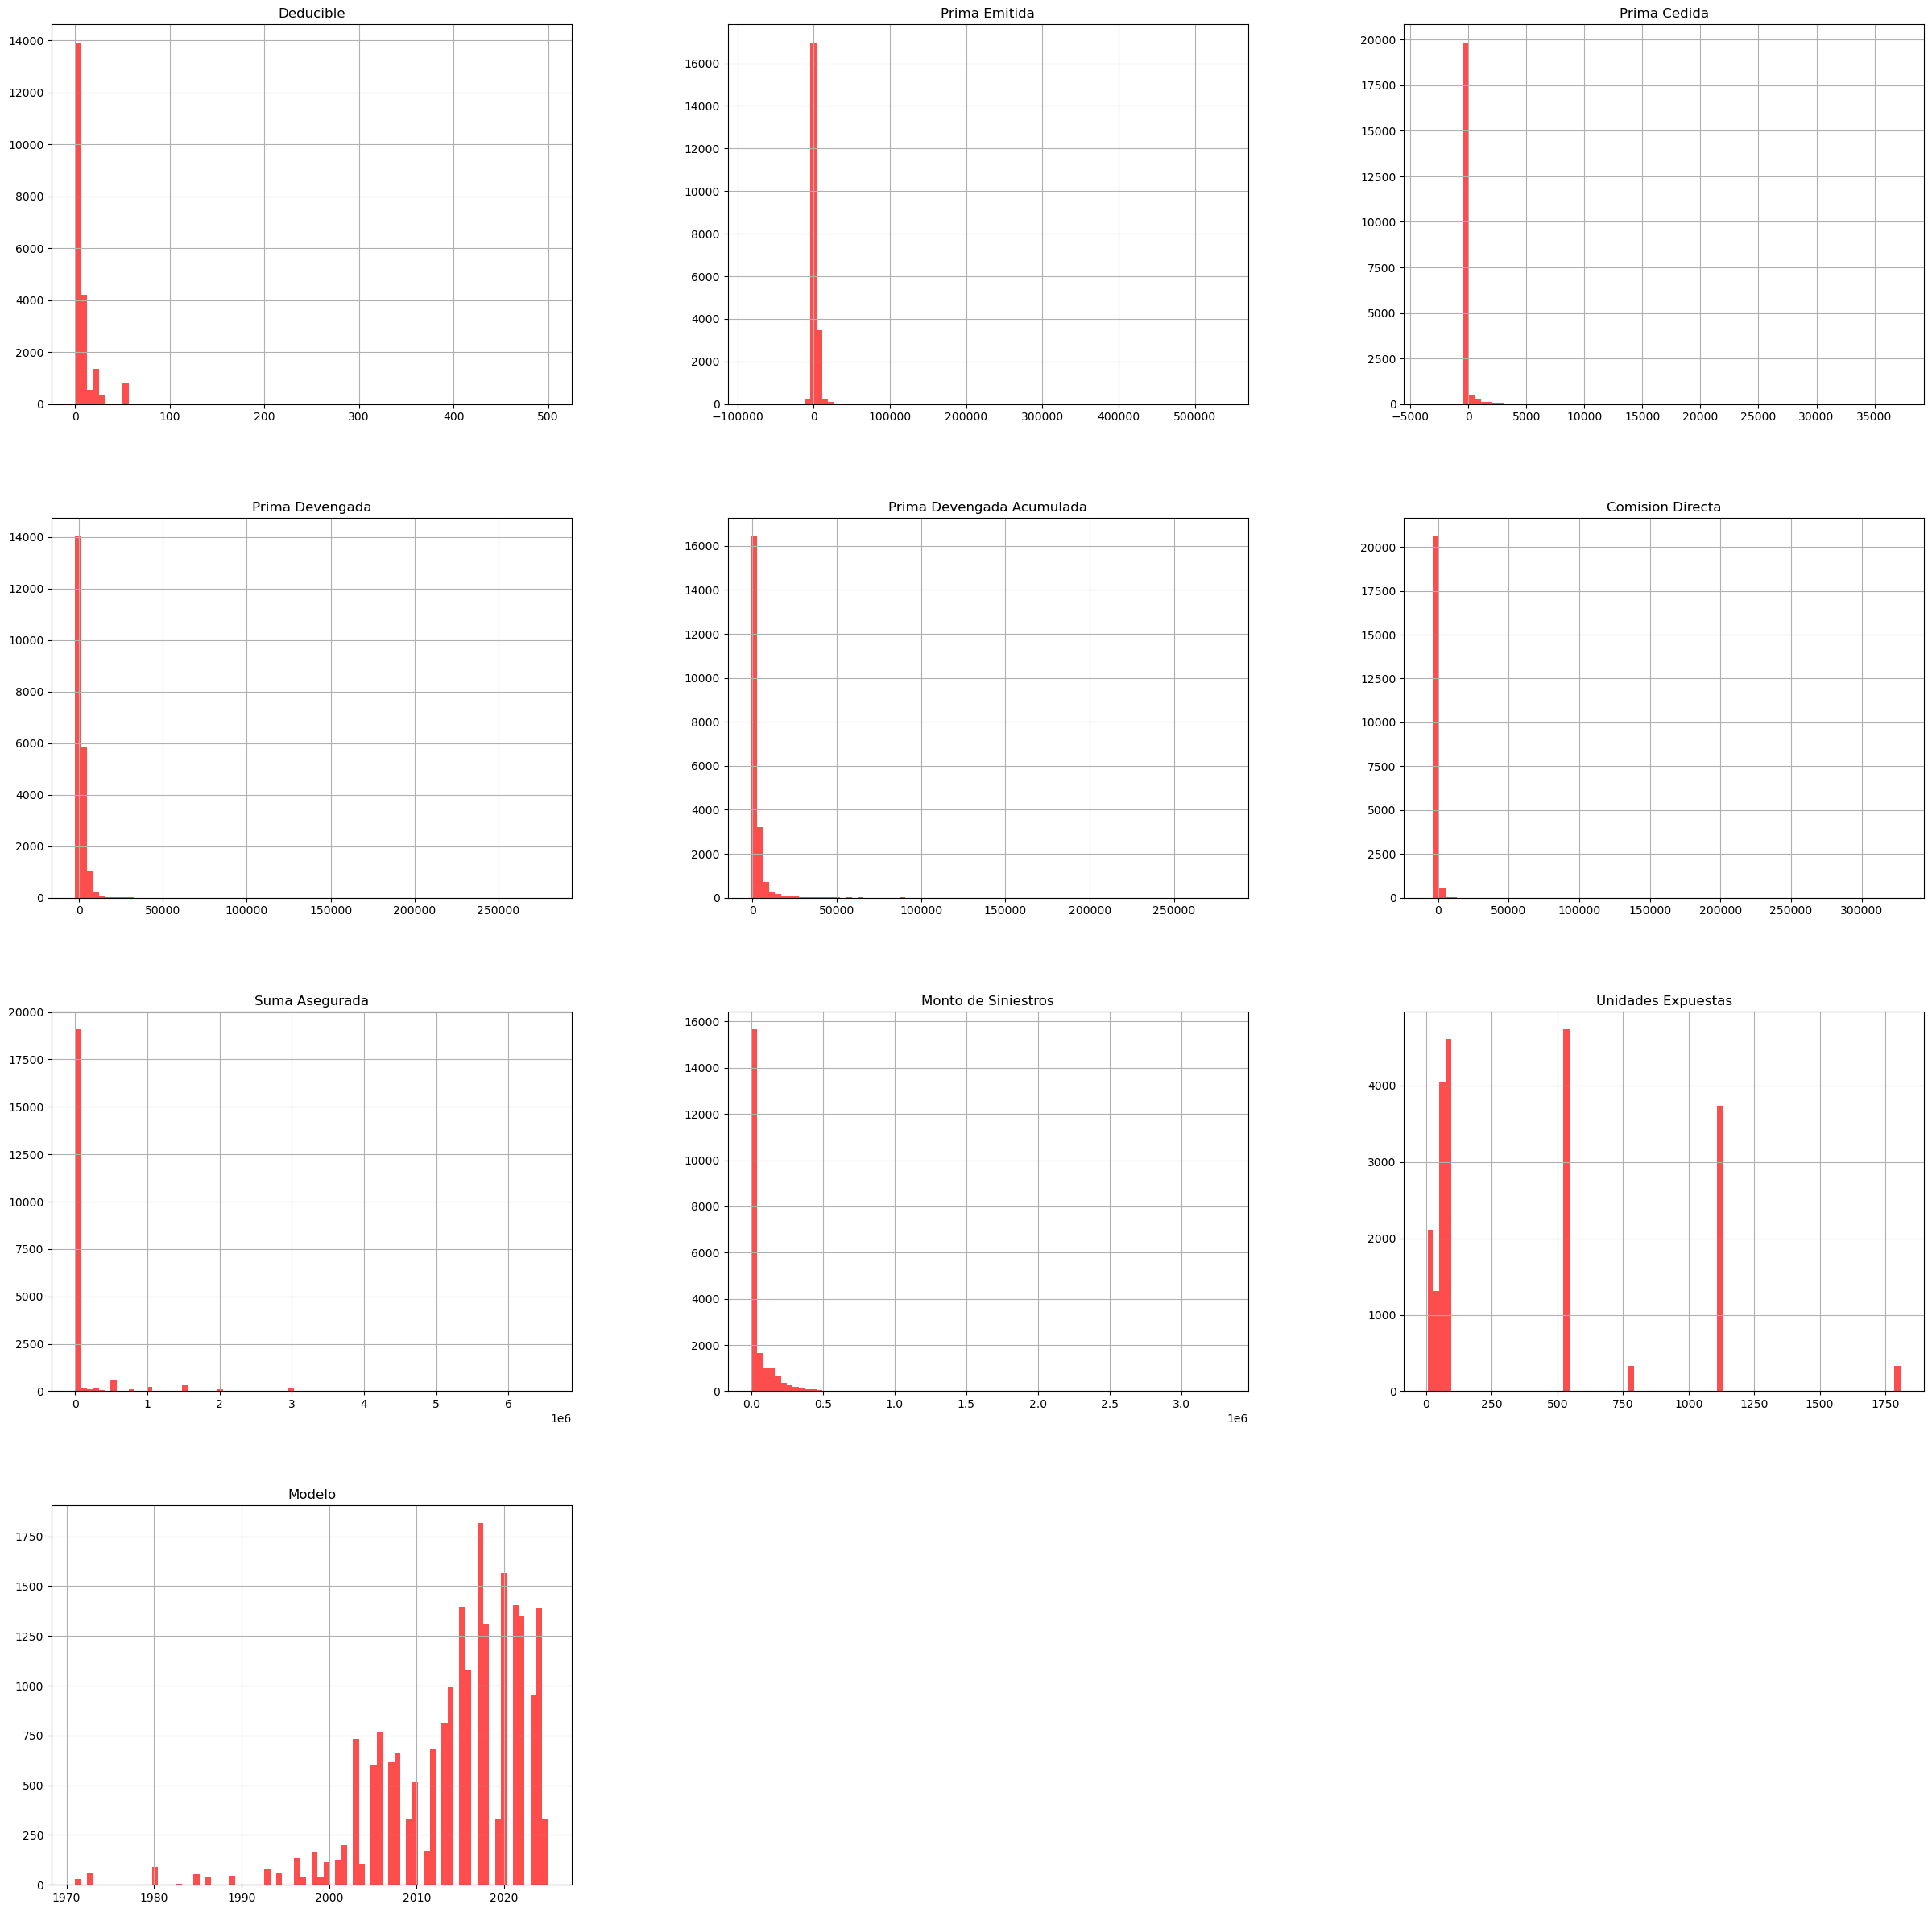

In [1633]:
# Histograma para todas las demás variables

df_num.hist(bins = 80, color = 'red', alpha=0.7, figsize=(30,30))
plt.show()

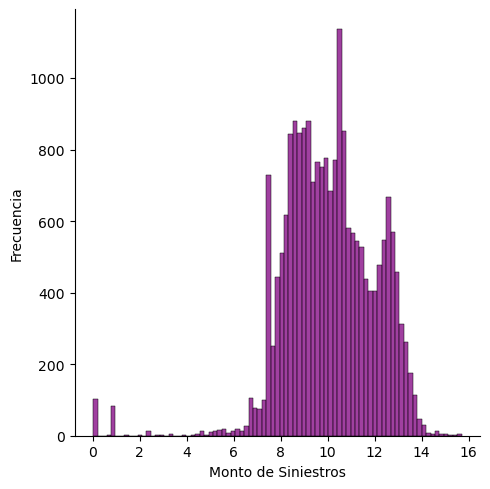

In [1634]:
# Histograma de la variable objetivo con transformación

sns.displot(df_num, x = np.arcsinh(df_num['Monto de Siniestros']), color = 'purple')
plt.ylabel("Frecuencia")
plt.show()

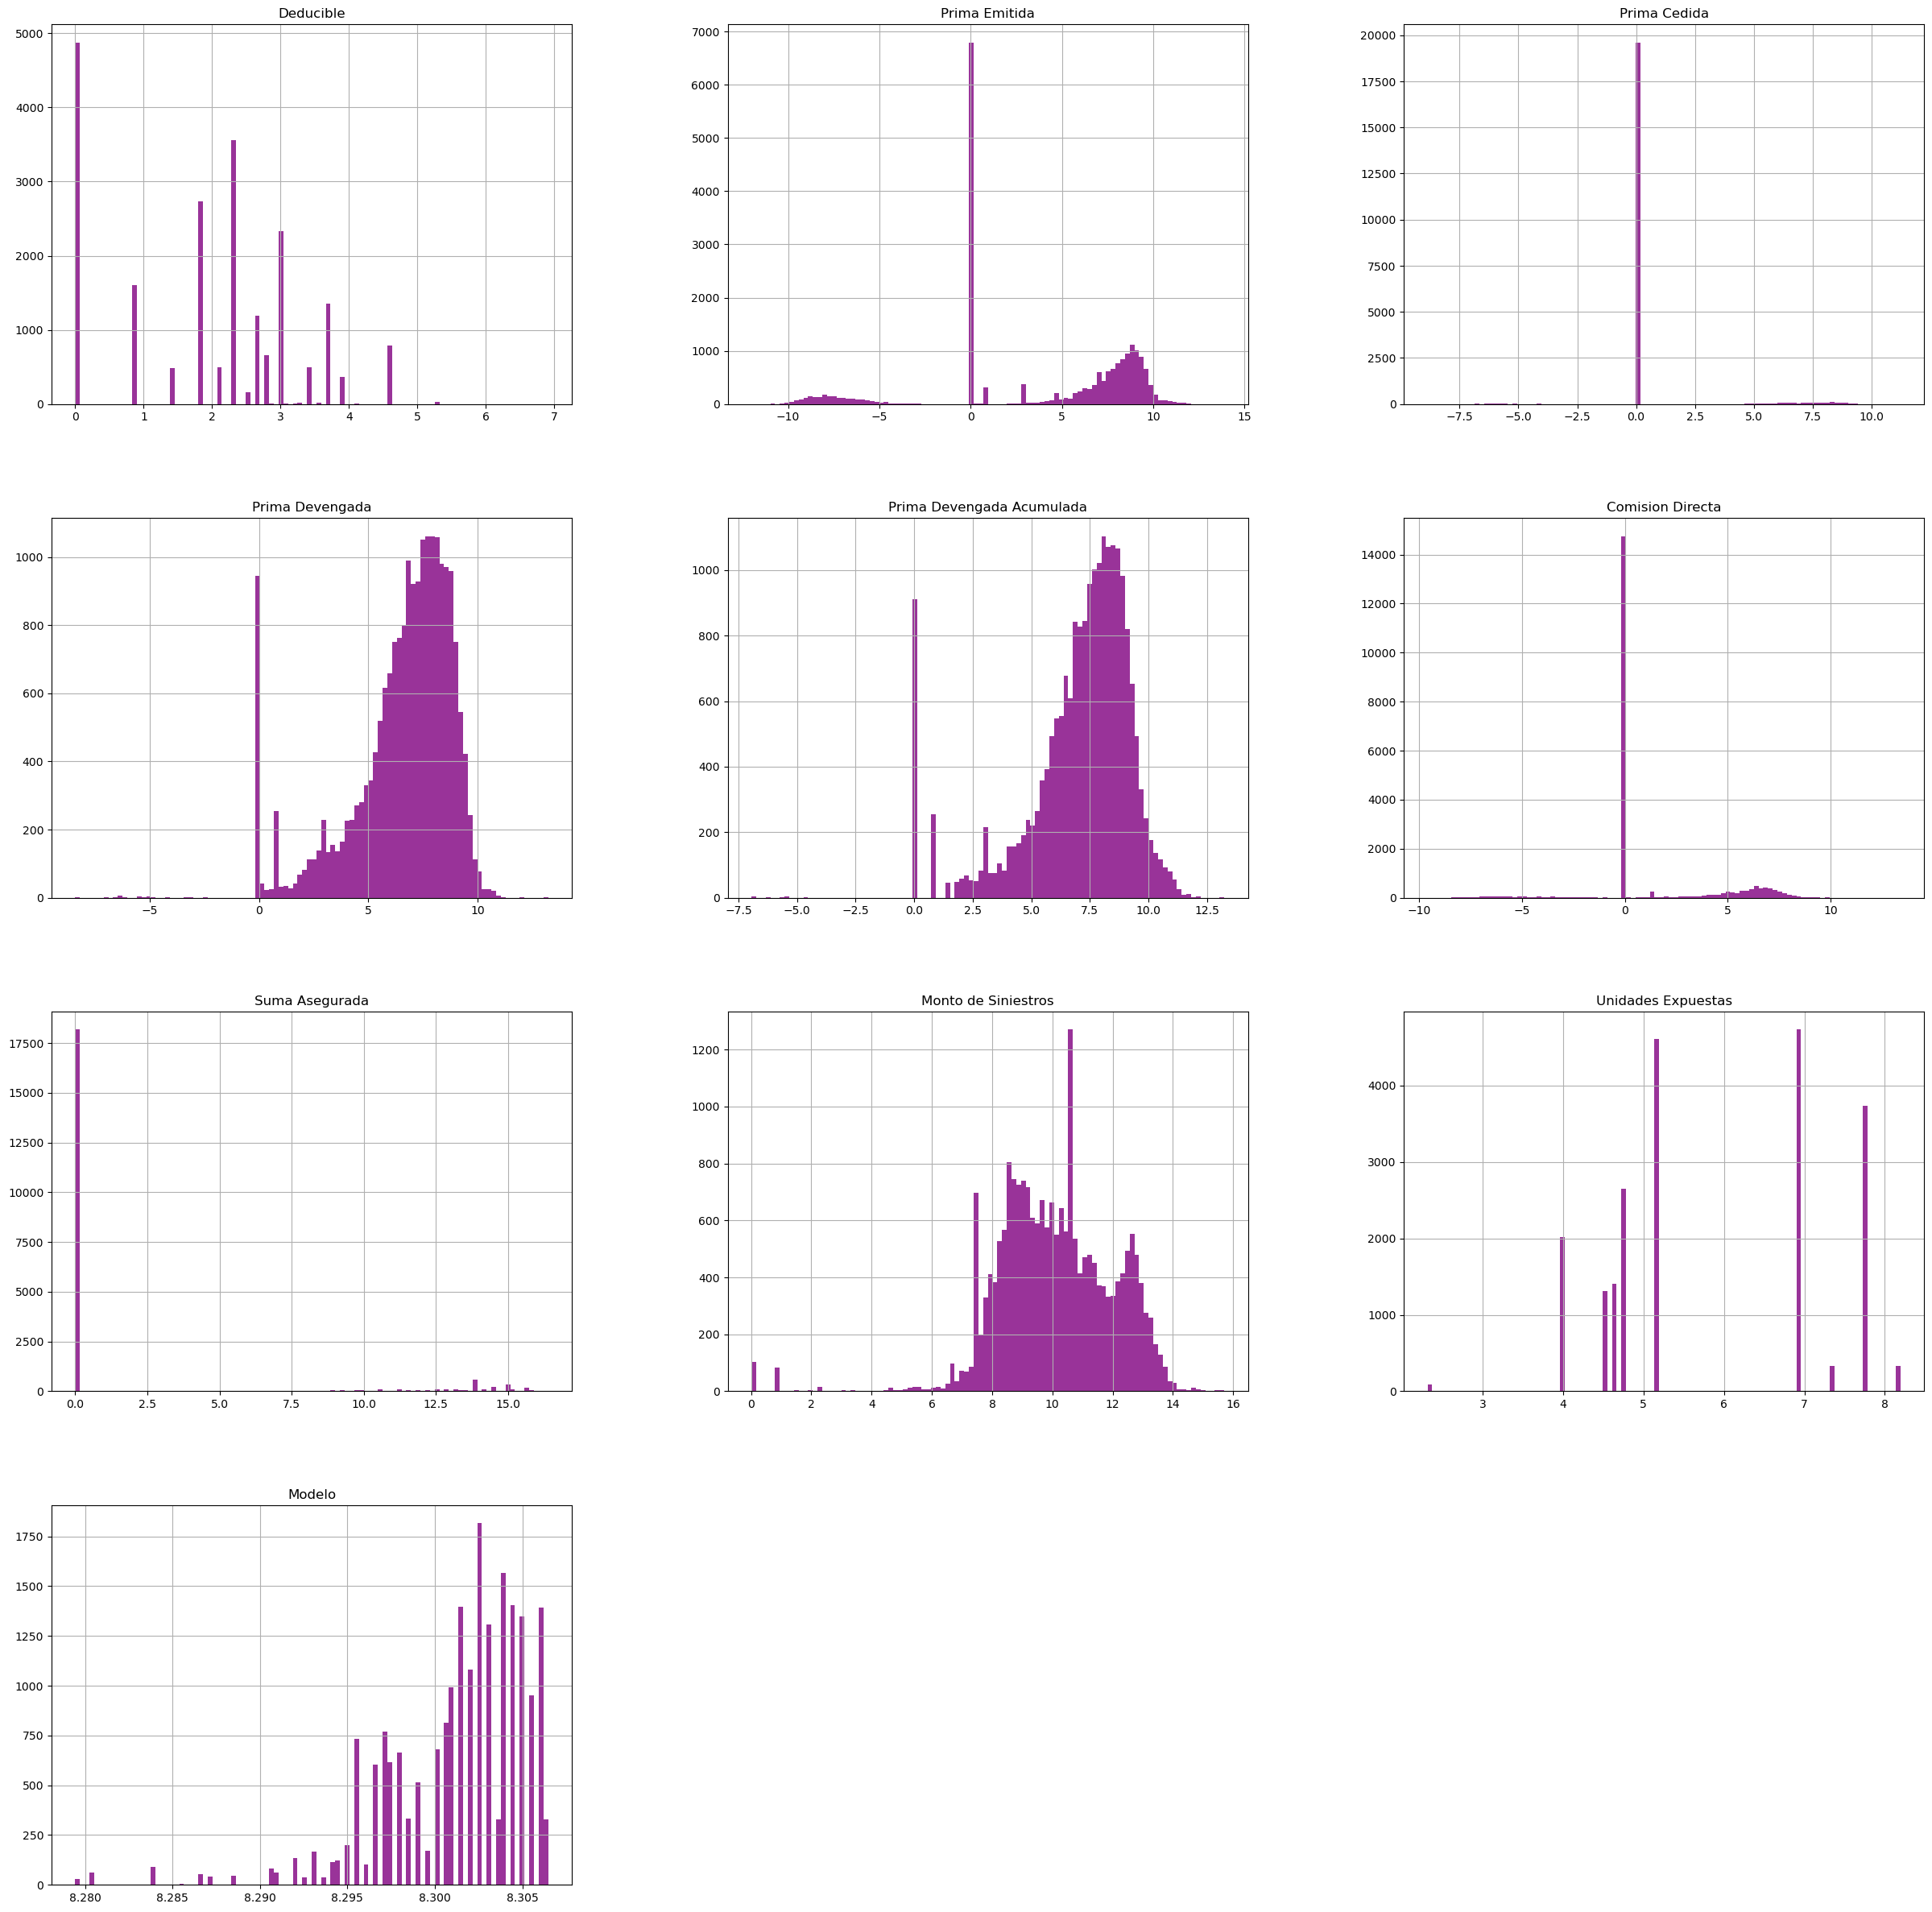

In [1635]:
# Histograma para todas las demás variables

np.arcsinh(df_num).hist(bins=100, alpha=0.8, figsize=(30,30), color = 'Purple')
plt.show()

#### SESGO

In [1636]:
print(df_num.select_dtypes(exclude=[object]).skew())

Deducible                      6.674668
Prima Emitida                 35.718392
Prima Cedida                  20.857250
Prima Devengada               43.144702
Prima Devengada Acumulada     13.478981
Comision Directa             134.206946
Suma Asegurada                 5.908539
Monto de Siniestros            9.161282
Unidades Expuestas             1.107077
Modelo                        -1.537489
dtype: float64


#### CORRELACIONES DE PEARSON Y SPEARMAN y FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)

In [1637]:
df_num.corr(method='pearson').style.background_gradient(cmap='coolwarm')

,Deducible,Prima Emitida,Prima Cedida,Prima Devengada,Prima Devengada Acumulada,Comision Directa,Suma Asegurada,Monto de Siniestros,Unidades Expuestas,Modelo
Deducible,1.000000,-0.005188,-0.066619,-0.021227,-0.034685,-0.004513,-0.140475,-0.030538,0.003291,0.057706
Prima Emitida,-0.005188,1.000000,0.280518,0.599944,0.361290,0.686029,-0.054736,0.035523,-0.032441,0.092495
Prima Cedida,-0.066619,0.280518,1.000000,0.051566,0.261675,0.008097,-0.020759,0.044430,-0.014995,0.040601
Prima Devengada,-0.021227,0.599944,0.051566,1.000000,0.727370,0.695010,-0.087312,0.043135,-0.066076,0.083567
Prima Devengada Acumulada,-0.034685,0.361290,0.261675,0.727370,1.000000,0.403860,-0.084857,0.046032,-0.073326,0.073802
Comision Directa,-0.004513,0.686029,0.008097,0.695010,0.403860,1.000000,-0.010660,0.003601,-0.003057,0.018060
Suma Asegurada,-0.140475,-0.054736,-0.020759,-0.087312,-0.084857,-0.010660,1.000000,0.049174,0.005724,-0.028060
Monto de Siniestros,-0.030538,0.035523,0.044430,0.043135,0.046032,0.003601,0.049174,1.000000,-0.053153,0.087029
Unidades Expuestas,0.003291,-0.032441,-0.014995,-0.066076,-0.073326,-0.003057,0.005724,-0.053153,1.000000,-0.209754
Modelo,0.057706,0.092495,0.040601,0.083567,0.073802,0.018060,-0.028060,0.087029,-0.209754,1.000000


In [1638]:
df_num.corr(method='spearman').style.background_gradient(cmap='coolwarm')

,Deducible,Prima Emitida,Prima Cedida,Prima Devengada,Prima Devengada Acumulada,Comision Directa,Suma Asegurada,Monto de Siniestros,Unidades Expuestas,Modelo
Deducible,1.000000,0.150669,-0.175354,0.128013,0.111808,0.104524,-0.298700,0.082569,-0.015215,0.054689
Prima Emitida,0.150669,1.000000,0.252227,0.327426,0.078508,0.561803,-0.144257,0.076825,-0.020448,0.157607
Prima Cedida,-0.175354,0.252227,1.000000,0.075013,0.018246,0.147224,0.021465,0.048370,0.003898,0.022157
Prima Devengada,0.128013,0.327426,0.075013,1.000000,0.880817,0.114377,-0.326599,0.133492,-0.064125,0.150660
Prima Devengada Acumulada,0.111808,0.078508,0.018246,0.880817,1.000000,-0.038263,-0.330052,0.131525,-0.066194,0.135075
Comision Directa,0.104524,0.561803,0.147224,0.114377,-0.038263,1.000000,-0.060877,0.021907,0.000039,0.050103
Suma Asegurada,-0.298700,-0.144257,0.021465,-0.326599,-0.330052,-0.060877,1.000000,-0.205242,0.033003,-0.032685
Monto de Siniestros,0.082569,0.076825,0.048370,0.133492,0.131525,0.021907,-0.205242,1.000000,-0.034899,0.100583
Unidades Expuestas,-0.015215,-0.020448,0.003898,-0.064125,-0.066194,0.000039,0.033003,-0.034899,1.000000,-0.263248
Modelo,0.054689,0.157607,0.022157,0.150660,0.135075,0.050103,-0.032685,0.100583,-0.263248,1.000000


In [1639]:
X = df_num.drop(columns=["Monto de Siniestros"])

vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

print(vif.sort_values("VIF", ascending=False))

                    Variable       VIF
3            Prima Devengada  5.063331
4  Prima Devengada Acumulada  3.175388
8                     Modelo  2.982927
5           Comision Directa  2.653893
1              Prima Emitida  2.621347
7         Unidades Expuestas  1.793508
0                  Deducible  1.458946
2               Prima Cedida  1.381142
6             Suma Asegurada  1.097729


#### DETECCIÓN DE VALORES ATÍPICOS Y DATOS FALTANTES

##### VALORES ATÍPICOS

###### DIAGRAMA DE CAJA

<Axes: xlabel='Monto de Siniestros'>

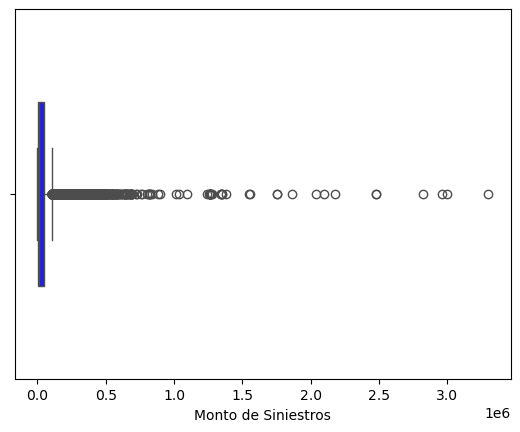

In [1640]:
sns.boxplot(df_num, x = 'Monto de Siniestros', width=.5, color = 'blue')


###### ZSCORE

In [1641]:
# Calculate z-score for each data point and compute its absolute value
z_scores = zscore(df_num['Monto de Siniestros'])
abs_z_scores = np.abs(z_scores)

# Select the outliers using a threshold of 3
outliers = df_num[abs_z_scores > 3]
outliers.loc[:, :'Monto de Siniestros'].head()

,Deducible,Prima Emitida,Prima Cedida,Prima Devengada,Prima Devengada Acumulada,Comision Directa,Suma Asegurada,Monto de Siniestros
0,0,0.00,0.0,432.85,587,0.00,0,447911.17
274,3,0.00,0.0,2133.53,4314,0.00,0,455803.00
372,25,270.20,0.0,268.73,270,0.00,0,577860.00
482,5,9592.92,0.0,3865.34,3865,0.00,0,433105.00
583,5,4934.88,0.0,1365.54,1366,740.23,0,448900.00


In [1642]:
print(f'Number of outliers: {len(outliers)}')

Number of outliers: 287


In [1643]:
# Visualizar todas las características del primer registro para mejor interpretación

df_sub.head(1)

,Marca,Deducible,Cobertura,Entidad,Tipo de Perdida,Subtipo de Seguro,Causa del siniestro,Prima Emitida,Prima Cedida,Prima Devengada,Prima Devengada Acumulada,Comision Directa,Suma Asegurada,Monto de Siniestros,Unidades Expuestas,Modelo,Segmento Clase,Combustible
0,125,0,1,17,2,0,99,0.0,0.0,432.85,587,0.0,0,447911.17,86.3891,2016,SUBCOMPACTO,GASOLINA/DIESEL


###### Z SCORE MODIFICADO

In [1644]:
# Set threshold to 3.5
mad = MAD(threshold = 3.5)

# Convert the 'total' column into a 2D numpy array
total_reshaped = df_num['Monto de Siniestros'].values.reshape(-1, 1)

# Generate inline and outlier labels
labels = mad.fit(total_reshaped).labels_
labels

array([1, 0, 1, ..., 0, 0, 0], shape=(21204,))

In [1645]:
# Obtain number of outliers
print(f'Number of outliers: {labels.sum()}')

Number of outliers: 4563


In [1646]:
outliers_MAD = df_num[labels == 1]
outliers_MAD.loc[:, :'Monto de Siniestros'].head()

,Deducible,Prima Emitida,Prima Cedida,Prima Devengada,Prima Devengada Acumulada,Comision Directa,Suma Asegurada,Monto de Siniestros
0,0,0.00,0.0,432.85,587,0.00,0,447911.17
2,5,-526.03,0.0,0.00,0,0.00,0,76912.00
8,5,0.00,0.0,1056.40,8677,0.00,0,140315.00
13,5,3022.51,0.0,1018.54,1019,302.00,0,120000.00
17,3,-5044.03,0.0,0.00,0,-756.61,0,238264.47


###### RANGO INTERCUARTÍLICO (IQR)

In [1647]:
# Calculate the percentiles
seventy_fifth = df_num['Monto de Siniestros'].quantile(0.75)
twenty_fifth = df_num['Monto de Siniestros'].quantile(0.25)

# Obtain IQR
iqr = seventy_fifth - twenty_fifth

# Upper and lower thresholds
upper = seventy_fifth + (1.5 * iqr)
lower = twenty_fifth - (1.5 * iqr)

# Subset the dataset
outliers_IQR = df_num[(df_num['Monto de Siniestros'] < lower) | (df_num['Monto de Siniestros'] > upper)]
outliers_IQR.loc[:, :'Monto de Siniestros'].head()

,Deducible,Prima Emitida,Prima Cedida,Prima Devengada,Prima Devengada Acumulada,Comision Directa,Suma Asegurada,Monto de Siniestros
0,0,0.00,0.0,432.85,587,0.00,0,447911.17
8,5,0.00,0.0,1056.40,8677,0.00,0,140315.00
13,5,3022.51,0.0,1018.54,1019,302.00,0,120000.00
17,3,-5044.03,0.0,0.00,0,-756.61,0,238264.47
19,3,-5044.03,0.0,0.00,0,-756.61,0,187400.00


In [1648]:
# OBTENER NÚMERO DE OUTLIERS
print(f'Number of outliers: {len(outliers_IQR)}')

Number of outliers: 3287


###### *TRATAMIENTO DE OUTLIERS CON WINSORIZACIÓN*

In [1649]:
df_w = df_sub.copy()
df_w['Monto de Siniestros'] = np.asarray(
    winsorize(df_sub['Monto de Siniestros'], limits =0.05)
)

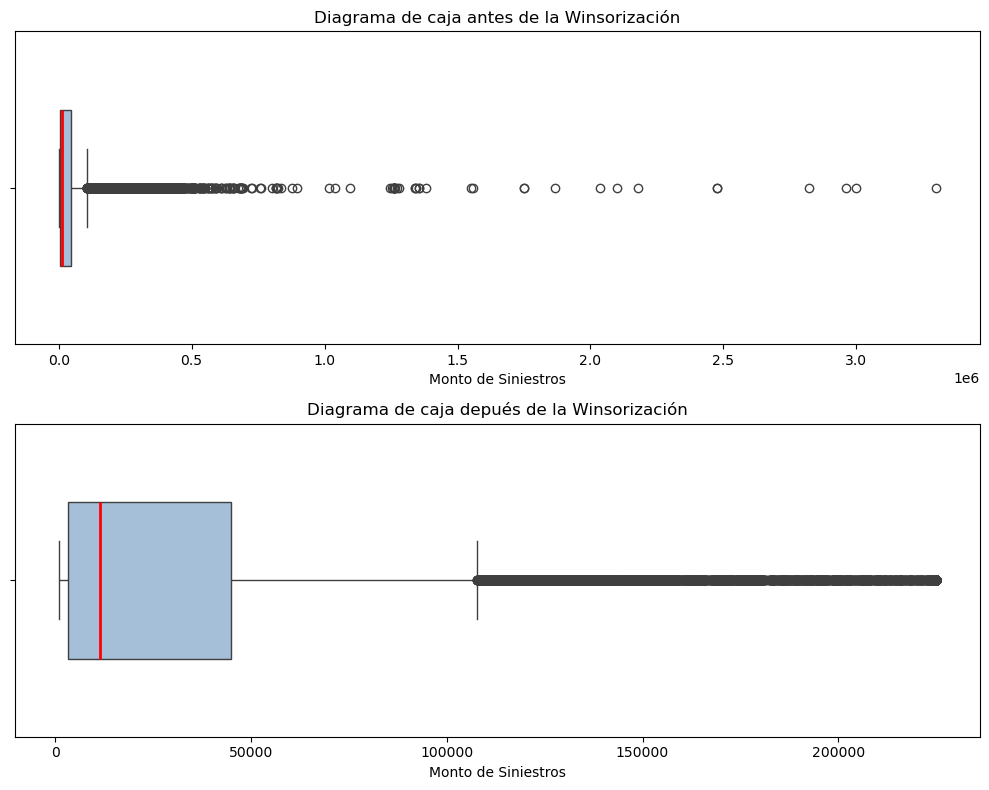

In [1650]:
# Tamaño y ejes

fig, axes = plt.subplots(2, 1, figsize = (10, 8))

# Crear un diagrama de caja antes y después

sns.boxplot(data = df_num, x = 'Monto de Siniestros', ax = axes[0], width = 0.5, boxprops={"facecolor": (.3, .5, .7, .5)},
    medianprops={"color": "r", "linewidth": 2})
sns.boxplot(data = df_w, x = 'Monto de Siniestros', ax = axes[1], width = 0.5, boxprops={"facecolor": (.3, .5, .7, .5)},
    medianprops={"color": "r", "linewidth": 2})

# Títulos y etiquetas

axes[0].set_title('Diagrama de caja antes de la Winsorización')
axes[1].set_title('Diagrama de caja depués de la Winsorización')
plt.tight_layout()

##### DATOS FALTANTES

In [1651]:
df_w.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21204 entries, 0 to 21203
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Marca                      21204 non-null  object 
 1   Deducible                  21204 non-null  int64  
 2   Cobertura                  21204 non-null  object 
 3   Entidad                    21204 non-null  object 
 4   Tipo de Perdida            21204 non-null  object 
 5   Subtipo de Seguro          21204 non-null  object 
 6   Causa del siniestro        21204 non-null  object 
 7   Prima Emitida              21204 non-null  float64
 8   Prima Cedida               21204 non-null  float64
 9   Prima Devengada            21204 non-null  float64
 10  Prima Devengada Acumulada  21204 non-null  int64  
 11  Comision Directa           21204 non-null  float64
 12  Suma Asegurada             21204 non-null  int64  
 13  Monto de Siniestros        21204 non-null  flo

In [1652]:
(df_w.select_dtypes('number') == 0).sum()

Deducible                     4876
Prima Emitida                 6735
Prima Cedida                 19603
Prima Devengada                685
Prima Devengada Acumulada      910
Comision Directa             14752
Suma Asegurada               18171
Monto de Siniestros              0
Unidades Expuestas               0
Modelo                           0
dtype: int64

### VARIABLES CATEGÓRICAS

In [1653]:
# Descripción de variables categóricas.
df_cat = df_sub.select_dtypes('object')
df_cat.describe().T   # cuenta: valores únicos, valor más frecuente, frecuencia.

,count,unique,top,freq
Marca,21204,211,473,342
Cobertura,21204,12,1,16045
Entidad,21204,33,15,1307
Tipo de Perdida,21204,8,1,5824
Subtipo de Seguro,21204,5,0,20078
Causa del siniestro,21204,20,6,10010
Segmento Clase,21204,2,COMPACTO,12228
Combustible,21204,4,GASOLINA,18802


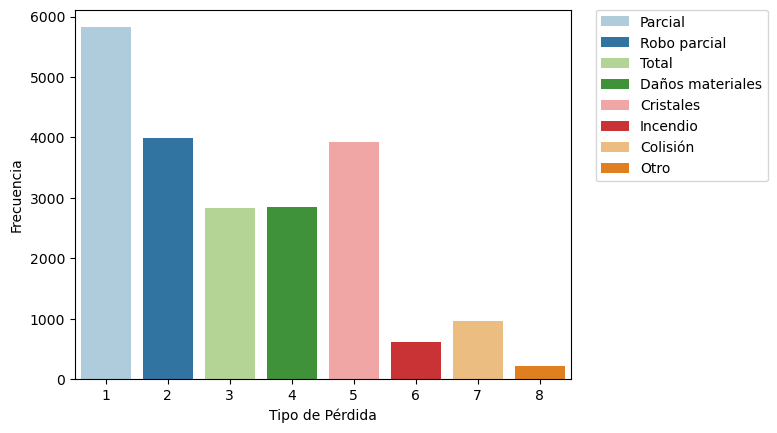

In [1654]:
mapa_perdida = {
    1: "Parcial",
    2: "Robo parcial",
    3: "Total",
    4: "Daños materiales",
    5: "Cristales",
    6: "Incendio",
    7: "Colisión",
    8: "Otro"
}
hue = df_cat["Tipo de Perdida"].map(mapa_perdida)

sns.countplot(
    data=df_cat,
    x="Tipo de Perdida",
    hue=hue,
    palette= sns.color_palette("Paired")
)

plt.xlabel("Tipo de Pérdida")
plt.ylabel("Frecuencia")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.show()

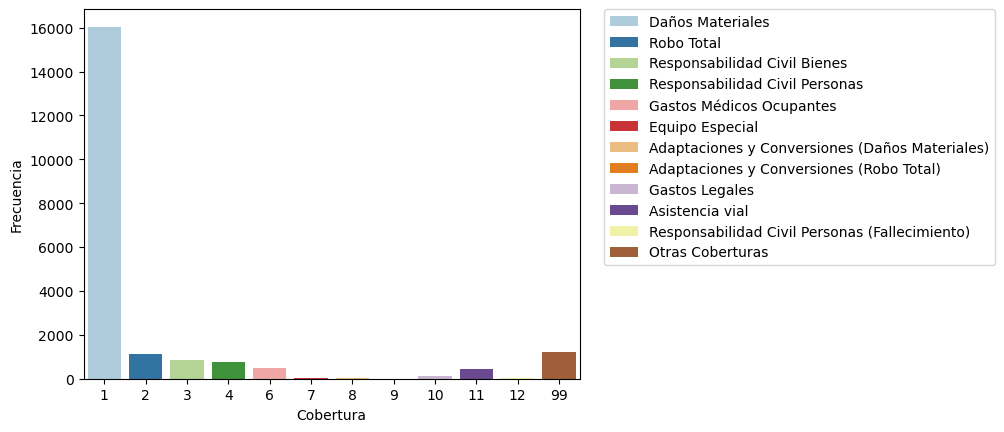

In [1655]:
mapa_cobertura = {
     1:	'Daños Materiales',
     2:	'Robo Total',
     3:	'Responsabilidad Civil Bienes',
     4:	'Responsabilidad Civil Personas',
     5:	'Responsabilidad Civil LUC (sólo aplica para emisión)',
     6:	'Gastos Médicos Ocupantes',
     7:	'Equipo Especial',
     8:	'Adaptaciones y Conversiones (Daños Materiales)',
     9:	'Adaptaciones y Conversiones (Robo Total)',
    10:	'Gastos Legales',
    11:	'Asistencia vial',
    12:	'Responsabilidad Civil Personas (Fallecimiento)',
    13:	'RC en Exceso',
    14:	'RC Obligatorio',
    99:	'Otras Coberturas'
}

hue = df_cat["Cobertura"].map(mapa_cobertura)

sns.countplot(
    data=df_cat,
    x="Cobertura",
    hue=hue,
    palette= sns.color_palette("Paired")
)

plt.xlabel("Cobertura")
plt.ylabel("Frecuencia")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.show()

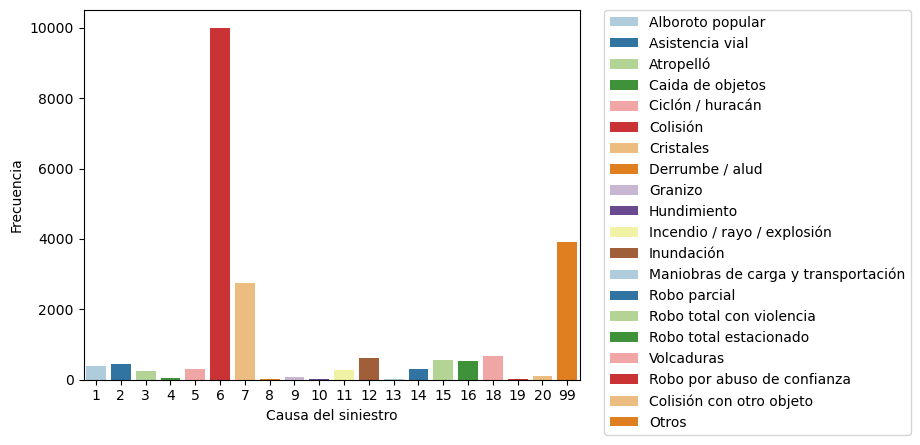

In [1656]:
mapa_causadelsiniestro = {

     1:	'Alboroto popular',
     2:	'Asistencia vial',
     3:	'Atropelló',
     4:	'Caida de objetos',
     5:	'Ciclón / huracán',
     6:	'Colisión',
     7:	'Cristales',
     8:	'Derrumbe / alud',
     9:	'Granizo',
    10:	'Hundimiento',
    11:	'Incendio / rayo / explosión',
    12:	'Inundación',
    13:	'Maniobras de carga y transportación',
    14:	'Robo parcial',
    15:	'Robo total con violencia',
    16:	'Robo total estacionado',
    17:	'Terremoto y/o erupción volcánica',
    18:	'Volcaduras',
    19:	'Robo por abuso de confianza',
    20:	'Colisión con otro objeto',
    99:	'Otros'
}

hue = df_cat["Causa del siniestro"].map(mapa_causadelsiniestro)

sns.countplot(
    data=df_cat,
    x="Causa del siniestro",
    hue=hue,
    palette= sns.color_palette("Paired")
)

plt.xlabel("Causa del siniestro")
plt.ylabel("Frecuencia")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.show()

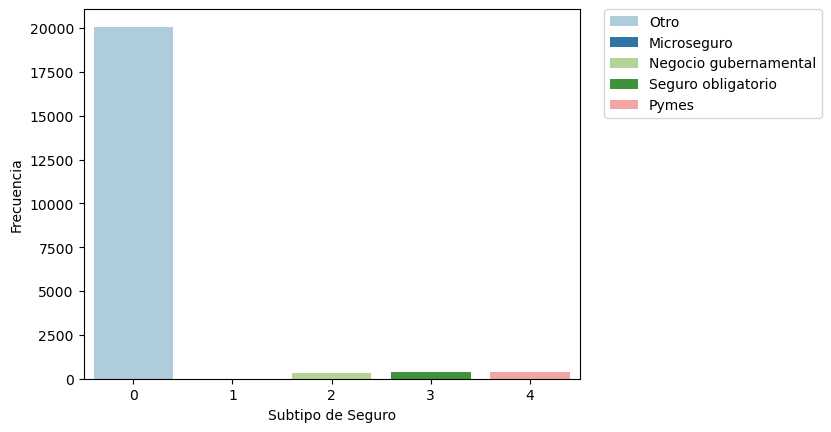

In [1657]:
mapa_subtiposeguro = {
    0:	'Otro',
    1:	'Microseguro',
    2:	'Negocio gubernamental',
    3:	'Seguro obligatorio',
    4:	'Pymes'
}

hue = df_cat["Subtipo de Seguro"].map(mapa_subtiposeguro)

sns.countplot(
    data=df_cat,
    x="Subtipo de Seguro",
    hue=hue,
    palette= sns.color_palette("Paired")
)

plt.xlabel("Subtipo de Seguro")
plt.ylabel("Frecuencia")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.show()

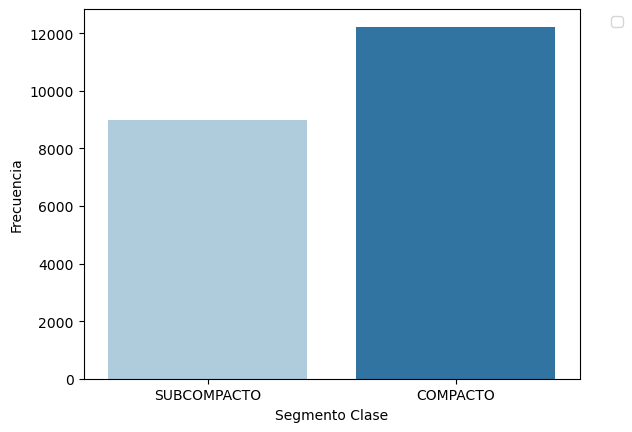

In [1658]:
sns.countplot(
    data=df_cat,
    x="Segmento Clase",
    hue='Segmento Clase',
    palette= sns.color_palette("Paired")
)

plt.xlabel("Segmento Clase")
plt.ylabel("Frecuencia")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

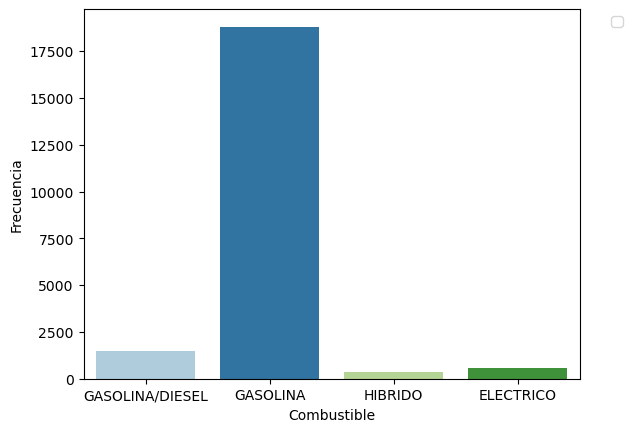

In [1659]:
sns.countplot(
    data=df_cat,
    x="Combustible",
    hue='Combustible',
    palette= sns.color_palette("Paired")
)

plt.xlabel("Combustible")
plt.ylabel("Frecuencia")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

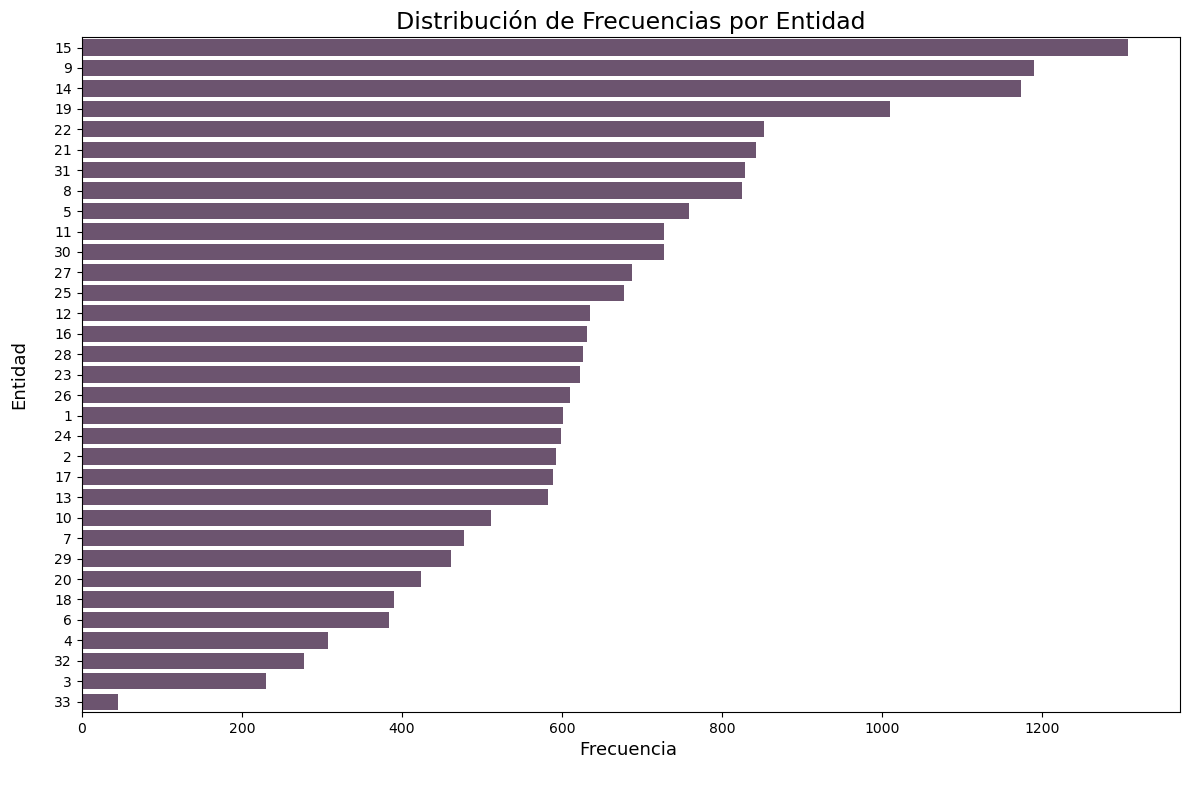

In [1660]:
mapa_entidad = {
     1:	'Aguascalientes',
     2:	'Baja California',
     3:	'Baja California Sur',
     4:	'Campeche',
     5:	'Coahuila',
     6:	'Colima',
     7:	'Chiapas',
     8:	'Chihuahua',
     9:	'Distrito Federal',
    10:	'Durango',
    11:	'Guanajuato',
    12:	'Guerrero',
    13:	'Hidalgo',
    14:	'Jalisco',
    15:	'Estado de México',
    16:	'Michoacán',
    17:	'Morelos',
    18:	'Nayarit',
    19:	'Nuevo León',
    20:	'Oaxaca',
    21:	'Puebla',
    22:	'Querétaro',
    23:	'Quintana Roo',
    24:	'San Luis Potosí',
    25:	'Sinaloa',
    26:	'Sonora',
    27:	'Tabasco',
    28:	'Tamaulipas',
    29:	'Tlaxcala',
    30:	'Veracruz',
    31:	'Yucatán',
    32:	'Zacatecas',
    33:	'Extranjero',
    34:	'Desconocido ó Sin domicilio fijo',
    99:	'No aplica (Exportación)'
}

plt.figure(figsize=(12,8))


sns.countplot(
    data=df_cat,
    y="Entidad",
    order=df_cat["Entidad"].value_counts().index,
    color="#6f4f74"
)

plt.title("Distribución de Frecuencias por Entidad", fontsize = 17)
plt.xlabel("Frecuencia \n", fontsize = 13)
plt.ylabel("Entidad\n ", fontsize = 13)
plt.tight_layout()
plt.show()

# **FEATURE ENGINEERING**



### ***CODIFICACIÓN DE VARIABLES CATEGÓRICAS***



ONE-HOT ENCONDING

In [1661]:
df_limpio = pd.get_dummies(df_w, columns = col_categoricas, drop_first=True ,prefix_sep="_", dtype=int)
df_limpio.head()

,Deducible,Prima Emitida,Prima Cedida,Prima Devengada,Prima Devengada Acumulada,Comision Directa,Suma Asegurada,Monto de Siniestros,Unidades Expuestas,Modelo,...,Causa del siniestro_15,Causa del siniestro_16,Causa del siniestro_18,Causa del siniestro_19,Causa del siniestro_20,Causa del siniestro_99,Segmento Clase_SUBCOMPACTO,Combustible_GASOLINA,Combustible_GASOLINA/DIESEL,Combustible_HIBRIDO
0,0,0.00,0.0,432.85,587,0.0,0,225000.00,86.3891,2016,...,0,0,0,0,0,1,1,0,1,0
1,50,1258.08,0.0,224.04,224,0.0,0,1832.00,1131.2844,2015,...,0,0,0,0,0,0,1,1,0,0
2,5,-526.03,0.0,0.00,0,0.0,0,76912.00,1131.2844,2010,...,0,1,0,0,0,0,1,1,0,0
3,5,-526.03,0.0,0.00,0,0.0,0,21324.86,1131.2844,2010,...,0,1,0,0,0,0,1,1,0,0
4,10,1948.63,0.0,475.15,475,526.0,0,20082.23,1807.3426,2009,...,0,0,0,0,0,1,1,1,0,0


# **MODELADO DE MONTO DE SINIESTROS**

## ***INSUMOS***

In [1662]:
df_limpio.head()

,Deducible,Prima Emitida,Prima Cedida,Prima Devengada,Prima Devengada Acumulada,Comision Directa,Suma Asegurada,Monto de Siniestros,Unidades Expuestas,Modelo,...,Causa del siniestro_15,Causa del siniestro_16,Causa del siniestro_18,Causa del siniestro_19,Causa del siniestro_20,Causa del siniestro_99,Segmento Clase_SUBCOMPACTO,Combustible_GASOLINA,Combustible_GASOLINA/DIESEL,Combustible_HIBRIDO
0,0,0.00,0.0,432.85,587,0.0,0,225000.00,86.3891,2016,...,0,0,0,0,0,1,1,0,1,0
1,50,1258.08,0.0,224.04,224,0.0,0,1832.00,1131.2844,2015,...,0,0,0,0,0,0,1,1,0,0
2,5,-526.03,0.0,0.00,0,0.0,0,76912.00,1131.2844,2010,...,0,1,0,0,0,0,1,1,0,0
3,5,-526.03,0.0,0.00,0,0.0,0,21324.86,1131.2844,2010,...,0,1,0,0,0,0,1,1,0,0
4,10,1948.63,0.0,475.15,475,526.0,0,20082.23,1807.3426,2009,...,0,0,0,0,0,1,1,1,0,0


In [1663]:
X = df_limpio.drop(columns=['Monto de Siniestros'])
y = df_limpio['Monto de Siniestros']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [1664]:
def evaluar_y_reportar(nombre, pipeline, X_train, X_test, y_train, y_test):
    pipeline.fit(X_train, y_train)

    pred_train = pipeline.predict(X_train)
    pred_test = pipeline.predict(X_test)

    r2_train = r2_score(y_train, pred_train)
    r2_test  = r2_score(y_test, pred_test)
    mae = mean_absolute_error(y_test, pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred_test))

    print(nombre)
    print("-" * len(nombre))
    print(f"Coeficiente de determinación (entrenamiento): {r2_train:.4f}")
    print(f"Coeficiente de determinación (prueba)       : {r2_test:.4f}")
    print(f"Error absoluto medio (prueba)              : {mae:,.2f}")
    print(f"Raíz del error cuadrático medio (prueba)   : {rmse:,.2f}")

    return {"modelo": nombre, "r2_entrenamiento": r2_train, "r2_prueba": r2_test, "mae": mae, "rmse": rmse}


def graficar_reales_vs_predichos(nombre, modelo_entrenado, X_test, y_test):
    pred_test = modelo_entrenado.predict(X_test)

    plt.figure(figsize=(10, 5))
    plt.scatter(y_test, pred_test, color = 'teal', alpha = 0.6, edgecolors = 'k', label = 'Observaciones')
    plt.plot([y_test.min(), y_test.max()],[pred_test.min(), pred_test.max()], 'r--', lw = 2, label = 'Línea ideal (y=x)')

    plt.xlabel("Valores reales")
    plt.ylabel("Valores predichos")
    plt.title(f"Valores reales vs predichos - {nombre}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def curva_aprendizaje(nombre, modelo, X, y, cv=5, n_points=8, n_jobs=-1, sample=None):
    """
    - n_points: cuántos tamaños evalúas (menos = más rápido)
    - sample: usa una fracción de datos para la curva (ej. 0.3) sin afectar el entrenamiento final
    """
    X_use, y_use = X, y
    if isinstance(sample, float) and 0 < sample <= 1:
        X_use, _, y_use, _ = train_test_split(X, y, train_size=sample, random_state=42)

    cv_strategy = ShuffleSplit(n_splits=cv, test_size=0.2, random_state=42)

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=modelo,
        X=X_use,
        y=y_use,
        train_sizes=np.linspace(0.1, 1.0, n_points),
        scoring="r2",
        cv=cv_strategy,
        shuffle=True,
        random_state=42,
        n_jobs=n_jobs
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.figure(figsize=(10, 5))
    plt.plot(train_sizes, train_mean, label="Entrenamiento")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)

    plt.plot(train_sizes, val_mean, label="Validación", linestyle="--")
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

    plt.title(f"Curva de aprendizaje - {nombre}")
    plt.xlabel("Tamaño del conjunto de entrenamiento")
    plt.ylabel("R²")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## ***REGRESIÓN LINEAL MÚLTIPLE***

### EVALUACIÓN DEL MODELO

Regresión Lineal Múltiple
-------------------------
Coeficiente de determinación (entrenamiento): 0.5971
Coeficiente de determinación (prueba)       : 0.6073
Error absoluto medio (prueba)              : 27,577.26
Raíz del error cuadrático medio (prueba)   : 41,425.30


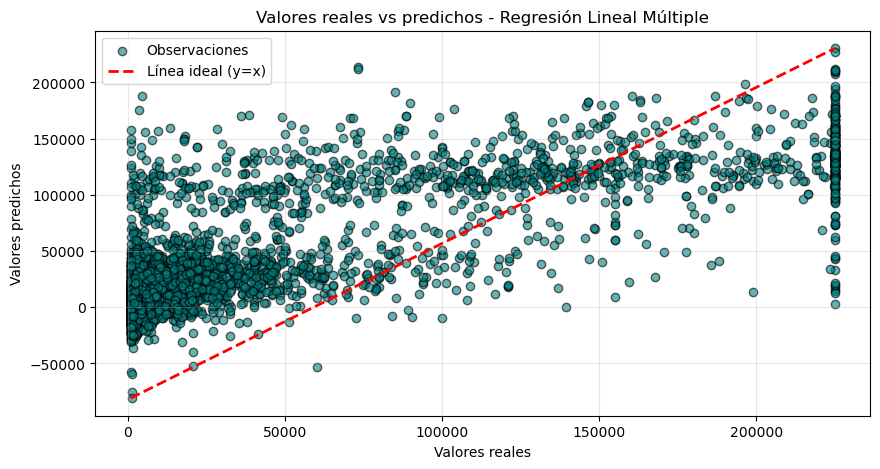

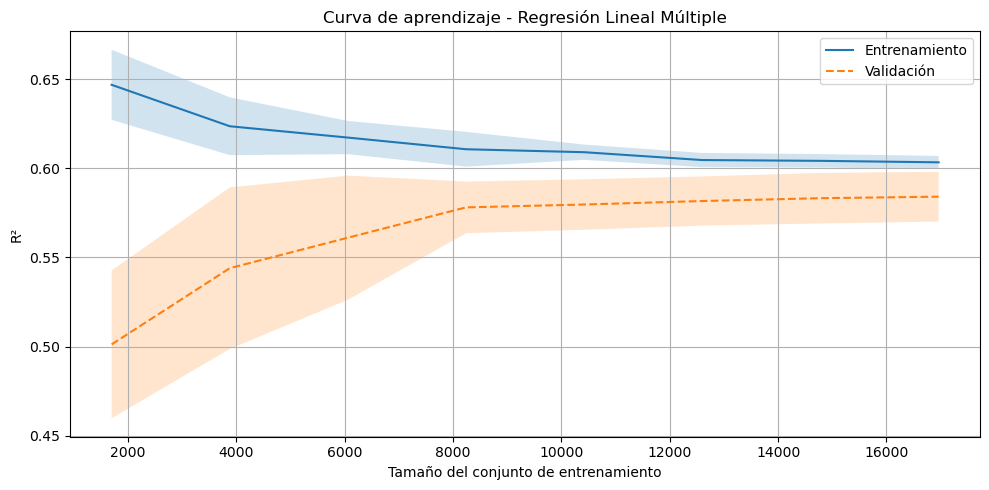

In [1665]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

linreg_pipeline = Pipeline(steps=[
    ("modelo", LinearRegression())
])

res_lr = evaluar_y_reportar("Regresión Lineal Múltiple", linreg_pipeline, X_train, X_test, y_train, y_test)
graficar_reales_vs_predichos("Regresión Lineal Múltiple", linreg_pipeline, X_test, y_test)
curva_aprendizaje("Regresión Lineal Múltiple", linreg_pipeline, X, y, cv=5)

### IMPORTANCIA DE VARIABLES SHAP

In [1666]:
explainer = shap.Explainer(linreg_pipeline.predict, X_test)
shap_values = explainer(X_test)

PermutationExplainer explainer: 4242it [02:33, 25.79it/s]


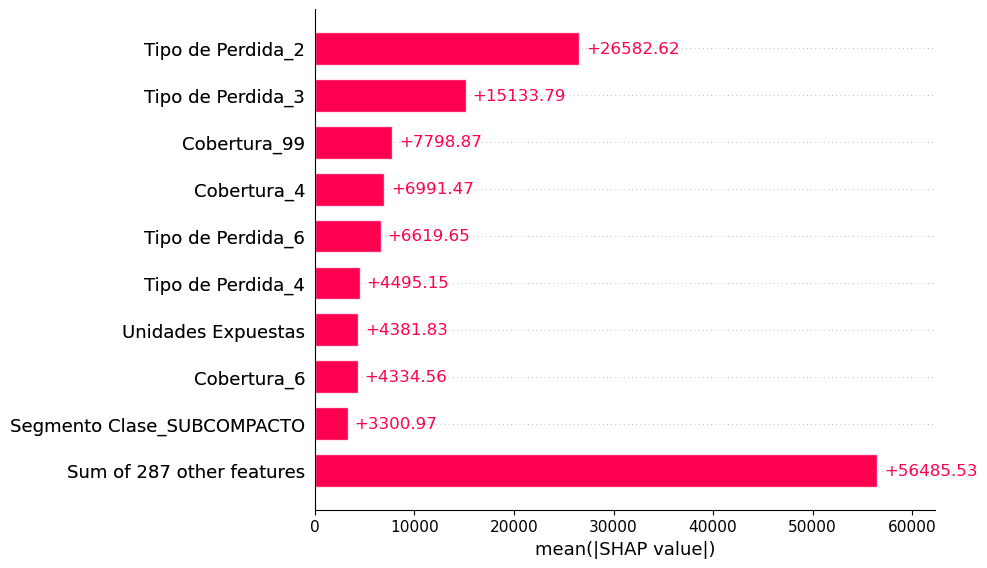

In [1667]:
shap.plots.bar(shap_values)

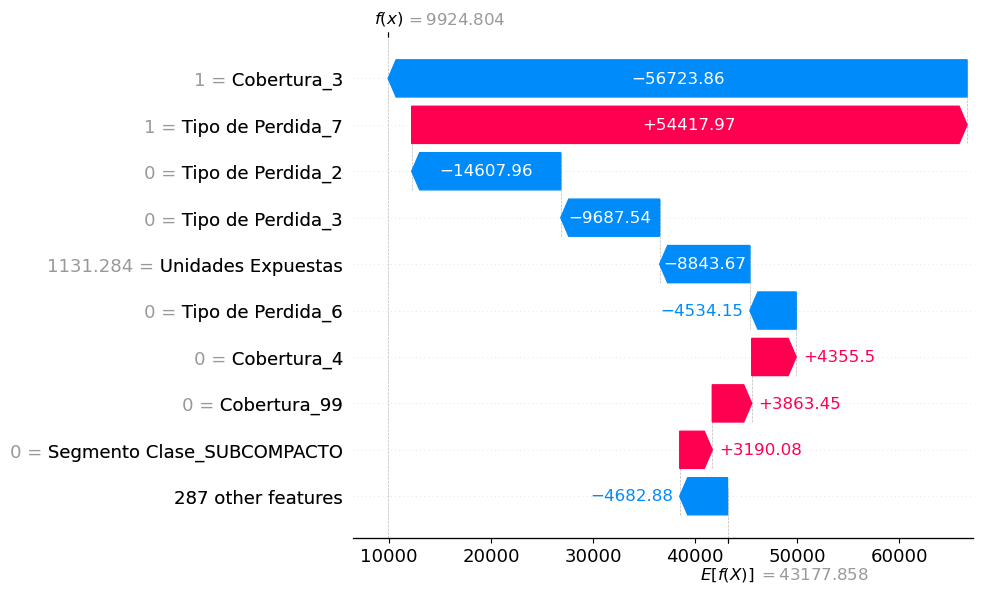

In [1668]:
shap.plots.waterfall(shap_values[0])

## ***RANDOM FOREST***

### EVALUACIÓN CON HIPERPARÁMETROS INICIALES

Random Forest Regressor
-----------------------
Coeficiente de determinación (entrenamiento): 0.6582
Coeficiente de determinación (prueba)       : 0.6509
Error absoluto medio (prueba)              : 23,501.73
Raíz del error cuadrático medio (prueba)   : 39,057.18


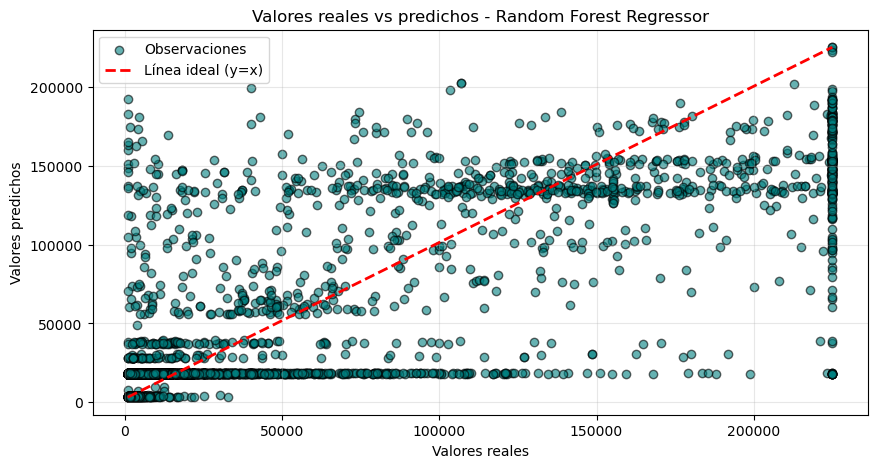

In [1669]:
rf_pipeline = Pipeline(steps=[
    ("modelo", RandomForestRegressor(
    n_estimators = 500,
    max_depth = 6,
    min_samples_split = 2,
    min_samples_leaf = 1
    ))
])

res_lr = evaluar_y_reportar("Random Forest Regressor",rf_pipeline, X_train, X_test, y_train, y_test)
graficar_reales_vs_predichos("Random Forest Regressor", rf_pipeline, X_test, y_test)

### BÚSQUEDA DE MEJORES HIPERPARÁMETROS

In [1670]:
rf_pipeline_2 = Pipeline(steps=[
    ("modelo", RandomForestRegressor(
    random_state=42,
    n_jobs=-1,
    ))
])

param_rf = {
    "modelo__n_estimators": randint(400, 801),      # 400 a 800
    "modelo__max_depth": randint(5, 11),            # 5 a 10
    "modelo__min_samples_split": randint(2, 6),     # 2 a 5
    "modelo__min_samples_leaf": randint(1, 3)       # 1 a 2
}

random_rf = RandomizedSearchCV(
    estimator=rf_pipeline_2,
    param_distributions=param_rf,
    n_iter=20,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_rf.fit(X_train, y_train)

mejor_rf = random_rf.best_estimator_

print("Mejores parámetros encontrados:")
print(random_rf.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores parámetros encontrados:
{'modelo__max_depth': 10, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 5, 'modelo__n_estimators': 744}


#### EVALUACIÓN DEL MODELO OPTIMIZADO

Random Forest Regressor
-----------------------
Coeficiente de determinación (entrenamiento): 0.7448
Coeficiente de determinación (prueba)       : 0.6792
Error absoluto medio (prueba)              : 21,963.85
Raíz del error cuadrático medio (prueba)   : 37,445.03


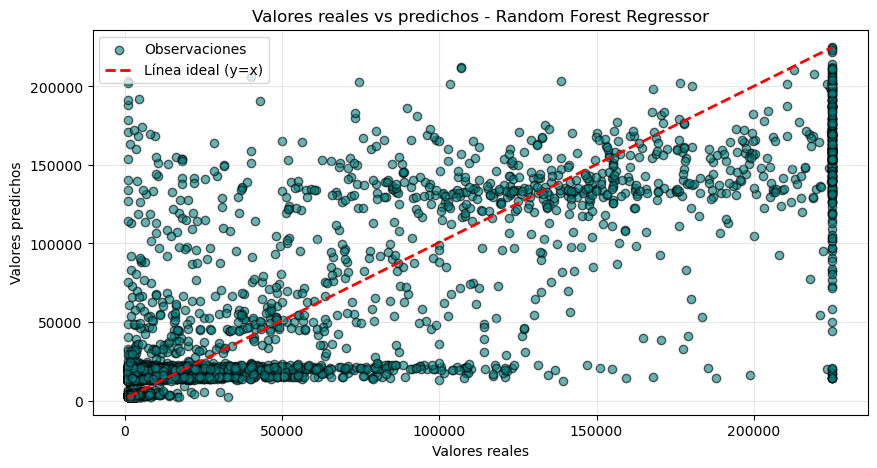

In [1671]:
res_rf = evaluar_y_reportar("Random Forest Regressor", mejor_rf, X_train, X_test, y_train, y_test)
graficar_reales_vs_predichos("Random Forest Regressor", mejor_rf, X_test, y_test)

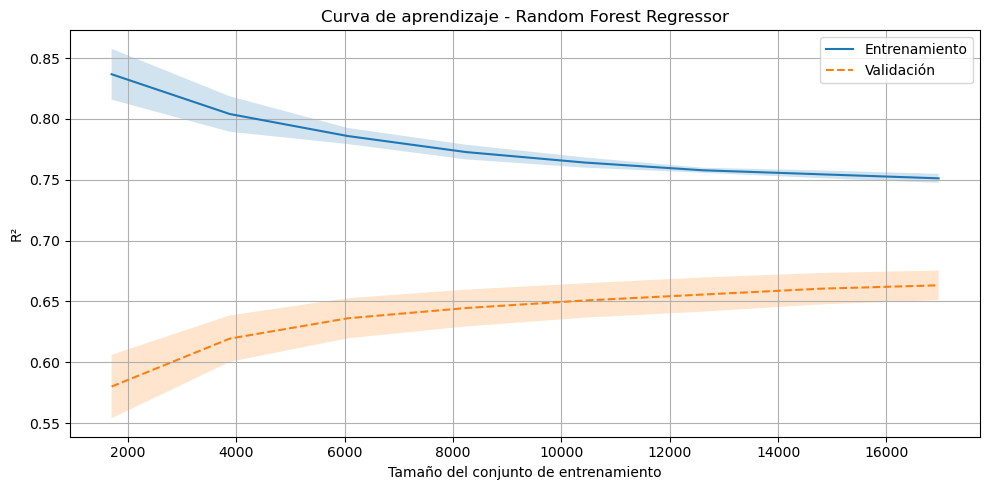

In [1672]:
curva_aprendizaje("Random Forest Regressor", mejor_rf, X, y, cv=5)

#### IMPORTANCIA DE VARIABLES SHAP



In [1673]:
explainer = shap.Explainer(mejor_rf.predict, X_test)
shap_values_RFR = explainer(X_test)

PermutationExplainer explainer: 4242it [31:51,  2.21it/s]


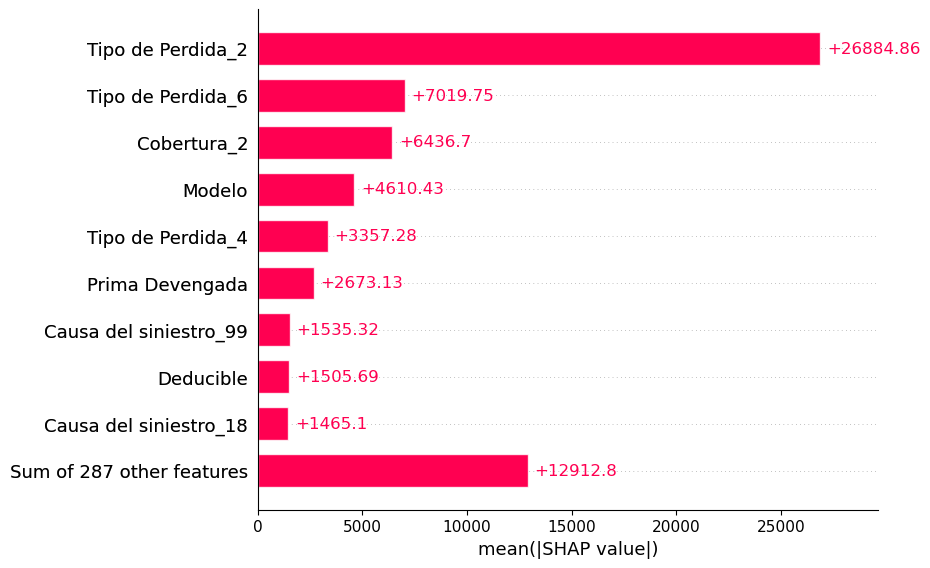

In [1674]:
shap.plots.bar(shap_values_RFR)

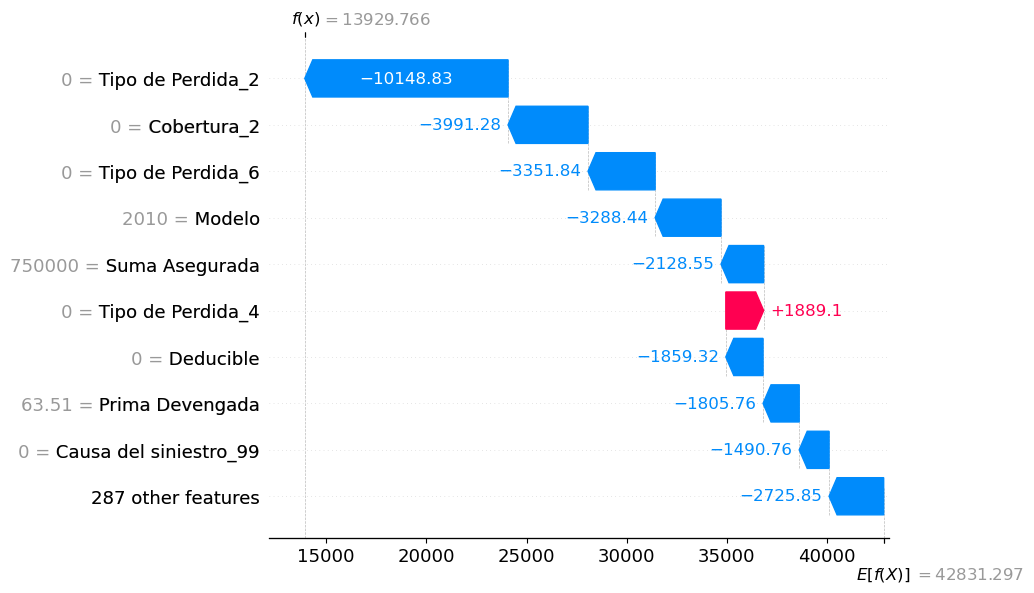

In [1675]:
shap.plots.waterfall(shap_values_RFR[0])

## ***XGBOOST***

### EVALUACIÓN CON HIPERPARÁMETROS INICIALES

XGBoost
-------
Coeficiente de determinación (entrenamiento): 0.7662
Coeficiente de determinación (prueba)       : 0.6959
Error absoluto medio (prueba)              : 21,446.80
Raíz del error cuadrático medio (prueba)   : 36,455.97


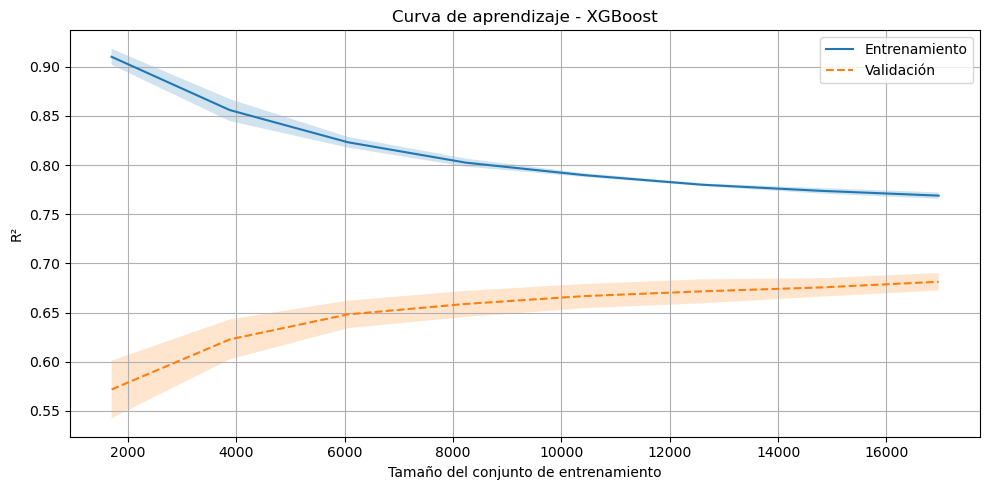

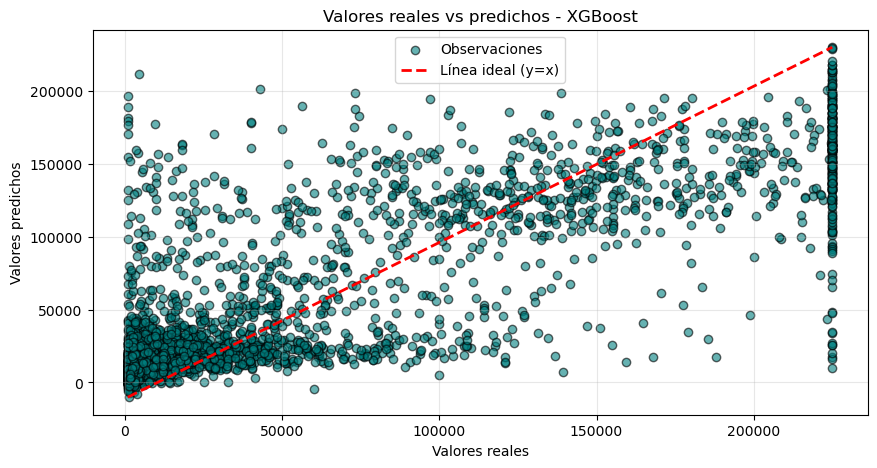

In [1676]:
xgb_pipeline = Pipeline(steps=[
    ("modelo", XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=2,
        reg_alpha=0.1,
        gamma=0,
        objective="reg:squarederror",
        tree_method="hist",
    ))
])

res_lr = evaluar_y_reportar("XGBoost",xgb_pipeline, X_train, X_test, y_train, y_test)
curva_aprendizaje("XGBoost", xgb_pipeline, X, y, cv=5)
graficar_reales_vs_predichos("XGBoost", xgb_pipeline, X_test, y_test)

### BÚSQUEDA DE MEJORES HIPERPARÁMETROS

In [1677]:
xgb_pipeline = Pipeline(steps=[
    ("modelo", XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42,
        n_jobs=1
    ))
])

param_dist_xgb = {
    "modelo__n_estimators": randint(300, 501),
    "modelo__max_depth": randint(2, 7),
    "modelo__learning_rate": uniform(0.001, 0.07),
    "modelo__subsample": uniform(0.6, 0.25),
    "modelo__colsample_bytree": uniform(0.6, 0.25),
    "modelo__min_child_weight": randint(3, 11),
    "modelo__gamma": uniform(0.0, 1.0),
    "modelo__reg_alpha": uniform(0.0, 1.0),
    "modelo__reg_lambda": uniform(1.0, 9.0)
}

random_xgb = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_xgb.fit(X_train, y_train)

mejor_xgb = random_xgb.best_estimator_

print("Mejores parámetros encontrados:")
print(random_xgb.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores parámetros encontrados:
{'modelo__colsample_bytree': np.float64(0.8357133926394953), 'modelo__gamma': np.float64(0.598865466488536), 'modelo__learning_rate': np.float64(0.04963494531277932), 'modelo__max_depth': 5, 'modelo__min_child_weight': 4, 'modelo__n_estimators': 469, 'modelo__reg_alpha': np.float64(0.808120379564417), 'modelo__reg_lambda': np.float64(6.700633808593811), 'modelo__subsample': np.float64(0.8178651475469294)}


#### EVALUACIÓN DEL MODELO OPTIMIZADO

XGBoost
-------
Coeficiente de determinación (entrenamiento): 0.7460
Coeficiente de determinación (prueba)       : 0.6932
Error absoluto medio (prueba)              : 21,577.45
Raíz del error cuadrático medio (prueba)   : 36,613.96


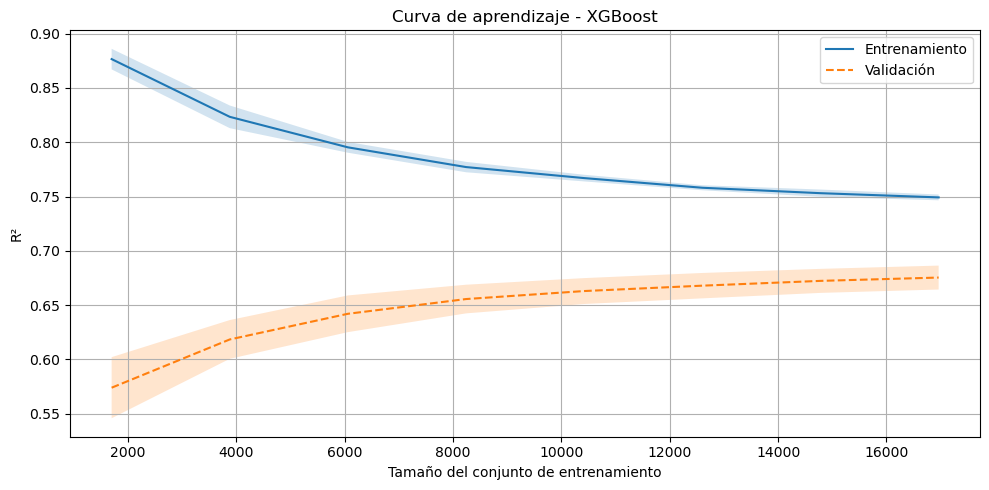

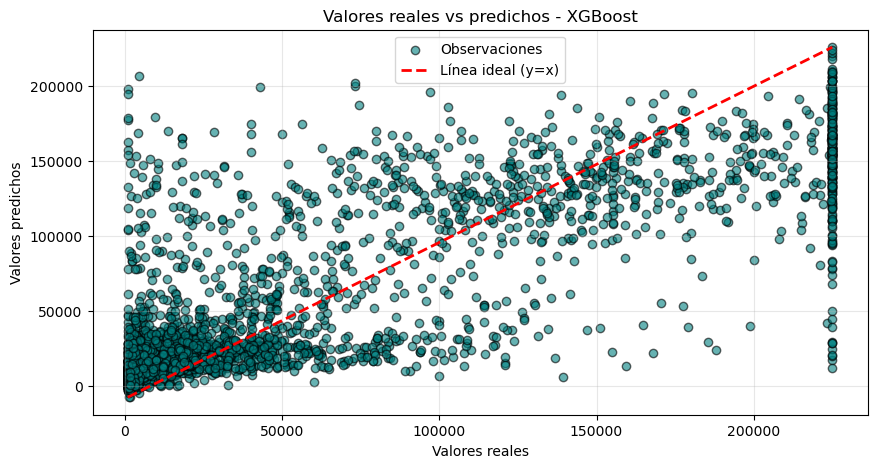

In [1678]:
res_xgb = evaluar_y_reportar("XGBoost", mejor_xgb, X_train, X_test, y_train, y_test)
curva_aprendizaje("XGBoost", mejor_xgb, X, y, cv=5)
graficar_reales_vs_predichos("XGBoost", mejor_xgb, X_test, y_test)

#### IMPORTANCIA DE VARIABLES SHAP

In [1679]:
explainer = shap.Explainer(mejor_xgb.predict, X_test)
shap_values_XGB = explainer(X_test)

PermutationExplainer explainer: 4242it [07:43,  8.96it/s]


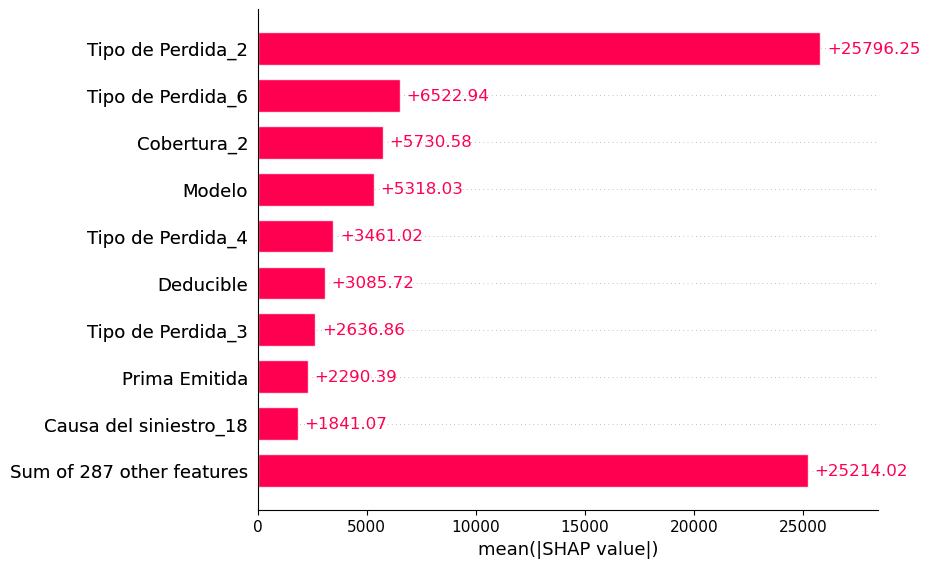

In [1680]:
shap.plots.bar(shap_values_XGB)

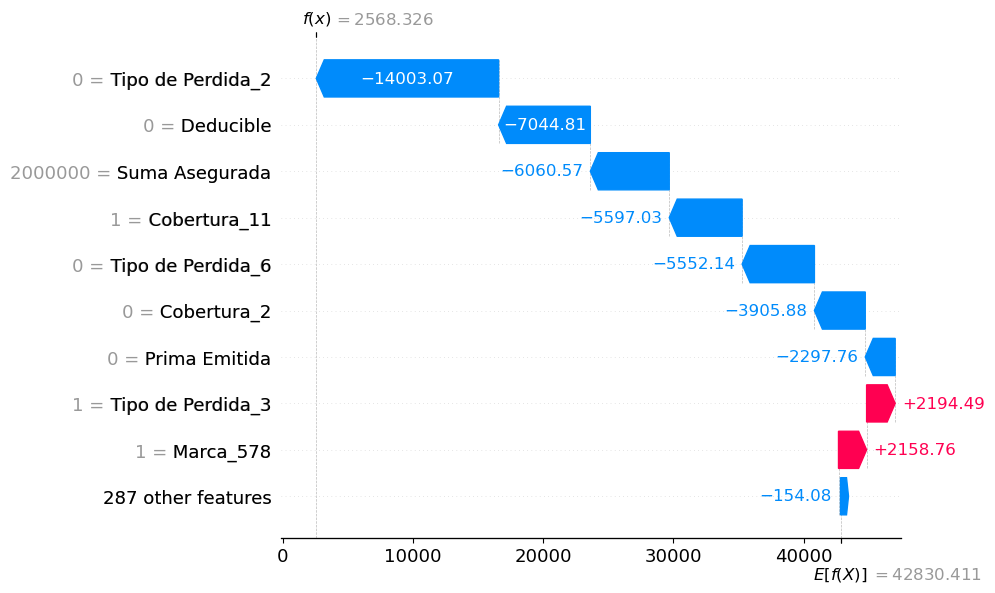

In [1684]:
shap.plots.waterfall(shap_values_XGB[1])

### VALIDACIÓN CRUAZADA DEL MEJOR MODELO

In [1682]:
cv = KFold(n_splits=10, shuffle=True, random_state=42)
scoring = {"r2":"r2", "mae":"neg_mean_absolute_error", "rmse":"neg_root_mean_squared_error"}

cv_xgb = cross_validate(mejor_xgb, X, y, cv=cv, scoring=scoring, n_jobs=-1)

print("XGBoost CV (5-fold)")
print("R2  :", np.mean(cv_xgb["test_r2"]),   "+/-", np.std(cv_xgb["test_r2"]))
print("MAE :", -np.mean(cv_xgb["test_mae"]), "+/-", np.std(-cv_xgb["test_mae"]))
print("RMSE:", -np.mean(cv_xgb["test_rmse"]),"+/-", np.std(-cv_xgb["test_rmse"]))

XGBoost CV (5-fold)
R2  : 0.6802955434250008 +/- 0.014499189909783975
MAE : 21375.480863083 +/- 527.6890558796007
RMSE: 36282.148437504875 +/- 636.5088970458592


## ***COMPARACIÓN Y ANÁLISIS***

In [1683]:
df_resultados = pd.DataFrame([res_lr, res_rf, res_xgb]).sort_values("rmse")
df_resultados

,modelo,r2_entrenamiento,r2_prueba,mae,rmse
0,XGBoost,0.766213,0.695882,21446.799193,36455.968747
2,XGBoost,0.745981,0.693240,21577.454729,36613.962989
1,Random Forest Regressor,0.744757,0.679156,21963.851890,37445.033046
